# Automatic Evaluation: LLM as a Jury & NER-based pipeline

### Init

In [1]:
import pandas as pd 
import numpy as np
import pickle
import os 
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg

In [2]:
criteria = ["Completeness", "Step_concordance", "Case_tailoring", "Missing_data_concordance", "MDT_Decision_Concordance"]
approaches = ["Model_Alone", "Model_Studies", "Model_Workflow", "Model_Workflow_Studies"]
approaches_names_map = {"Model_Alone":"LLM-baseline", "Model_Studies":"RAG-LLM", "Model_Workflow":"WF-LLM", "Model_Workflow_Studies":"WF-RAG-LLM"}

In [ ]:
model_dir_names = ["us.anthropic.claude-sonnet-4-6", "gpt-4o", "us.meta.llama3-3-70b-instruct-v10"]
model_names = {"us.anthropic.claude-sonnet-4-6":"Claude Sonnet 4.6", "gpt-4o":"GPT-4o", "us.meta.llama3-3-70b-instruct-v10":"Llama 3.3 70B"}

# Read data and build one dataset 
min_max_values = {m:[] for m in model_dir_names}

version = "v8"
# data path
model_dirs = {m:f"results_{m}" for m in model_dir_names} # add version subdir if needed 

# res path 
res_dir = f"results/{version}_overall_results_recommendation"

In [3]:
n_case_eval = 110

In [4]:
def compute_stats(values_):
    return [round(np.mean(values_),3), round(np.std(values_),3), round(np.median(values_),3), [round(np.percentile(values_, 25), 3), round(np.percentile(values_, 75), 3)]]

def statistics(list_score: list):
    statistics = {}
    statistics["Mean"] = round(np.nanmean(list_score), 2)
    statistics["STD"] = round(np.nanstd(list_score), 2)
    statistics["Median"] = round(np.nanmedian(list_score), 2)
    statistics["Percentiles_25-75"] = [round(np.nanpercentile(list_score, 25), 2), round(np.nanpercentile(list_score, 75), 2)]
    return statistics

### LLM-as-a-Jury

In [18]:
model_dirs

{'us.anthropic.claude-sonnet-4-6': 'results_us.anthropic.claude-sonnet-4-6',
 'gpt-4o': 'results_gpt-4o',
 'us.meta.llama3-3-70b-instruct-v10': 'results_us.meta.llama3-3-70b-instruct-v10'}

In [19]:
eval_final_data = pd.DataFrame(columns=["Approach","Judge","Criterion","Mean_Score", "STD_Score", "Median_Score", "Percentiles_25_75"])
for m in model_dirs.keys():
    d = model_dirs[m]
    m_files = os.listdir(d)
    for a in approaches: 
        f_name = f"{d}/eval_{a}_with_explanation.csv"
        f_content = pd.read_csv(f_name, sep=';')
        print(f"Approach --> {len(f_content)}")
        for c in criteria:
            c_col = f_content.loc[:,c].values
            stats_ = compute_stats(c_col)
            # print(stats_[0:-2] + [f"{stats_[3][0]}-{stats_[3][1]}"])
            eval_final_data.loc[len(eval_final_data)] = [a, m, c] + stats_[0:-1] + [f"{stats_[3][0]}-{stats_[3][1]}"]

Approach --> 110
Approach --> 110
Approach --> 110
Approach --> 110
Approach --> 110
Approach --> 110
Approach --> 110
Approach --> 110
Approach --> 110
Approach --> 110
Approach --> 110
Approach --> 110


In [20]:
eval_final_data

,Approach,Judge,Criterion,Mean_Score,STD_Score,Median_Score,Percentiles_25_75
0,Model_Alone,us.anthropic.claude-sonnet-4-6,Completeness,4.373,0.616,4.0,4.0-5.0
1,Model_Alone,us.anthropic.claude-sonnet-4-6,Step_concordance,3.627,0.724,4.0,3.0-4.0
2,Model_Alone,us.anthropic.claude-sonnet-4-6,Case_tailoring,3.791,0.634,4.0,3.0-4.0
3,Model_Alone,us.anthropic.claude-sonnet-4-6,Missing_data_concordance,3.600,0.946,4.0,4.0-4.0
4,Model_Alone,us.anthropic.claude-sonnet-4-6,MDT_Decision_Concordance,3.509,0.850,4.0,3.0-4.0
5,Model_Studies,us.anthropic.claude-sonnet-4-6,Completeness,4.664,0.491,5.0,4.0-5.0
6,Model_Studies,us.anthropic.claude-sonnet-4-6,Step_concordance,3.745,0.653,4.0,3.0-4.0
7,Model_Studies,us.anthropic.claude-sonnet-4-6,Case_tailoring,4.045,0.706,4.0,4.0-4.75
8,Model_Studies,us.anthropic.claude-sonnet-4-6,Missing_data_concordance,3.955,0.624,4.0,4.0-4.0
9,Model_Studies,us.anthropic.claude-sonnet-4-6,MDT_Decision_Concordance,3.655,0.791,4.0,3.0-4.0


In [21]:
# Normalization per model (judge)
new_columns=["Approach","Judge","Iteration","Criterion"]
eval_final_data_normalized = pd.DataFrame(columns=new_columns)
for m in model_dir_names:
    data_normalized = eval_final_data.loc[eval_final_data["Judge"]==m, "Approach":"Criterion"]
    m_r_data = eval_final_data.loc[eval_final_data["Judge"]==m, "Mean_Score"].values
    min_max_values[m] = [np.min(m_r_data), np.max(m_r_data)]
    print(f"Model judge: {m} --> len: {len(m_r_data)}; min_max: {min_max_values[m]}")
    normalized_values = (m_r_data - min_max_values[m][0])/(min_max_values[m][1]-min_max_values[m][0])
    round_values = [round(n,3) for n in normalized_values]
    data_normalized.insert(len(data_normalized.columns), "Mean_Score_Normalized", round_values)

    eval_final_data_normalized = pd.concat([eval_final_data_normalized, data_normalized])

Model judge: us.anthropic.claude-sonnet-4-6 --> len: 20; min_max: [np.float64(3.509), np.float64(4.682)]
Model judge: gpt-4o --> len: 20; min_max: [np.float64(4.055), np.float64(4.927)]
Model judge: us.meta.llama3-3-70b-instruct-v10 --> len: 20; min_max: [np.float64(4.3), np.float64(4.864)]


In [22]:
# Choose if you want to use normalized or non-normalized data for further analysis
eval_final_data = eval_final_data_normalized

In [25]:
summary_eval_tb = pd.DataFrame(columns=["Judge", "Criterion", "Approach", "Mean_Score_Across_Iteration"])
summary_eval_tb_for_graph = pd.DataFrame(columns=["Judge", "Criterion", "Approach", "Mean_Score_Across_Iteration", "STD_Score_Across_Iteration"])
for m in model_dir_names:
    for c in criteria:
        for a in approaches:
            data_a_m_c = eval_final_data.loc[(eval_final_data["Approach"]==a) & (eval_final_data["Judge"]==m) & (eval_final_data["Criterion"]==c),"Mean_Score_Normalized"].values
            summary_mean = round(np.mean(data_a_m_c),3)
            summary_std = round(np.std(data_a_m_c),3)
            print(f"Approach {a}, Judge: {m}, Criterion: {c}: {data_a_m_c} --> {summary_mean}")
            summary_eval_tb.loc[len(summary_eval_tb)] = [model_names[m], c, approaches_names_map[a], f"{summary_mean} ({summary_std})"]
            summary_eval_tb_for_graph.loc[len(summary_eval_tb_for_graph)] = [model_names[m], c, approaches_names_map[a], summary_mean, summary_std]

Approach Model_Alone, Judge: us.anthropic.claude-sonnet-4-6, Criterion: Completeness: [0.737] --> 0.737
Approach Model_Studies, Judge: us.anthropic.claude-sonnet-4-6, Criterion: Completeness: [0.985] --> 0.985
Approach Model_Workflow, Judge: us.anthropic.claude-sonnet-4-6, Criterion: Completeness: [0.767] --> 0.767
Approach Model_Workflow_Studies, Judge: us.anthropic.claude-sonnet-4-6, Criterion: Completeness: [1.] --> 1.0
Approach Model_Alone, Judge: us.anthropic.claude-sonnet-4-6, Criterion: Step_concordance: [0.101] --> 0.101
Approach Model_Studies, Judge: us.anthropic.claude-sonnet-4-6, Criterion: Step_concordance: [0.201] --> 0.201
Approach Model_Workflow, Judge: us.anthropic.claude-sonnet-4-6, Criterion: Step_concordance: [0.163] --> 0.163
Approach Model_Workflow_Studies, Judge: us.anthropic.claude-sonnet-4-6, Criterion: Step_concordance: [0.349] --> 0.349
Approach Model_Alone, Judge: us.anthropic.claude-sonnet-4-6, Criterion: Case_tailoring: [0.24] --> 0.24
Approach Model_Studie

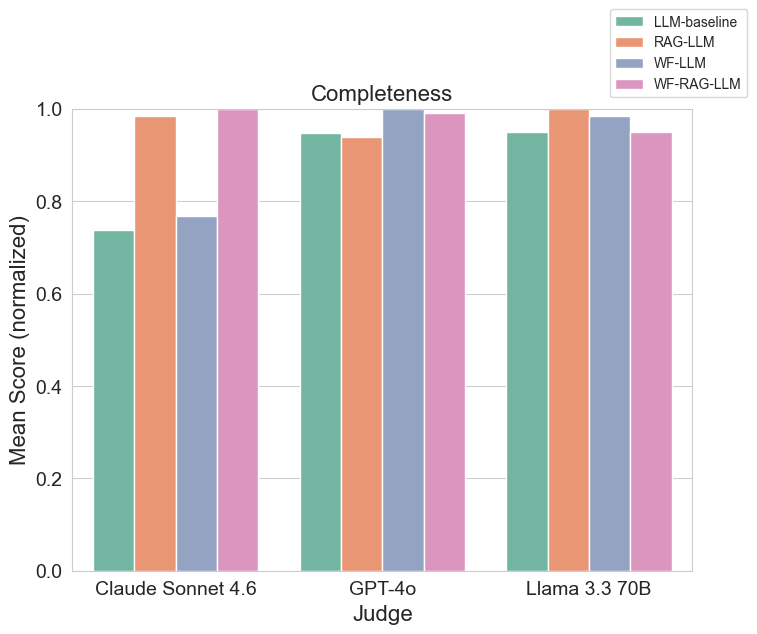

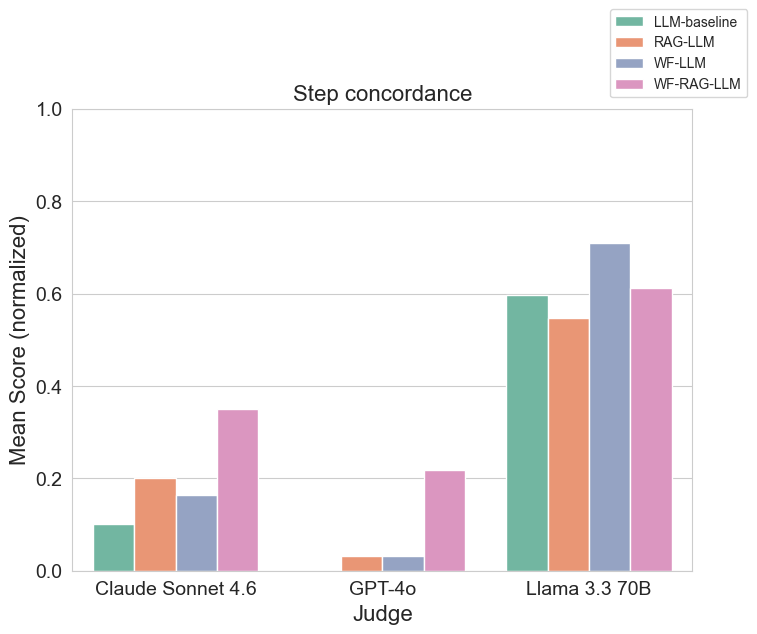

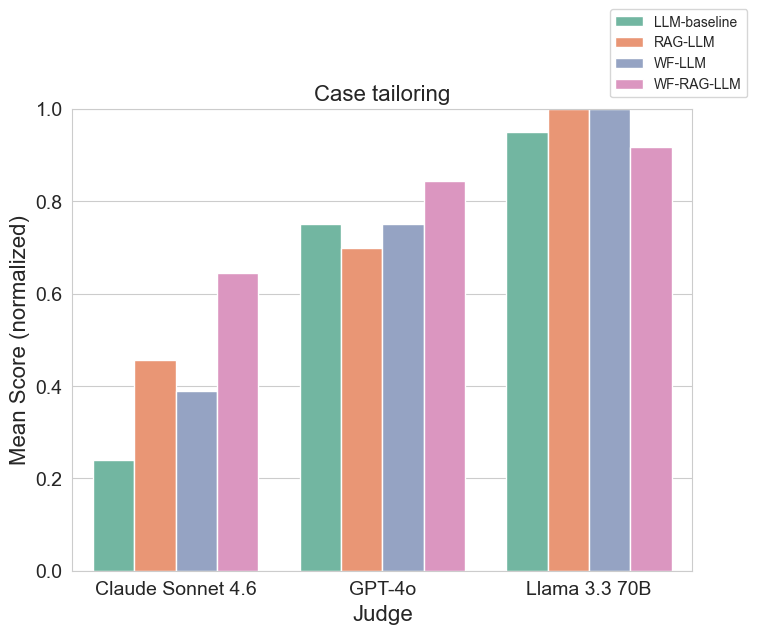

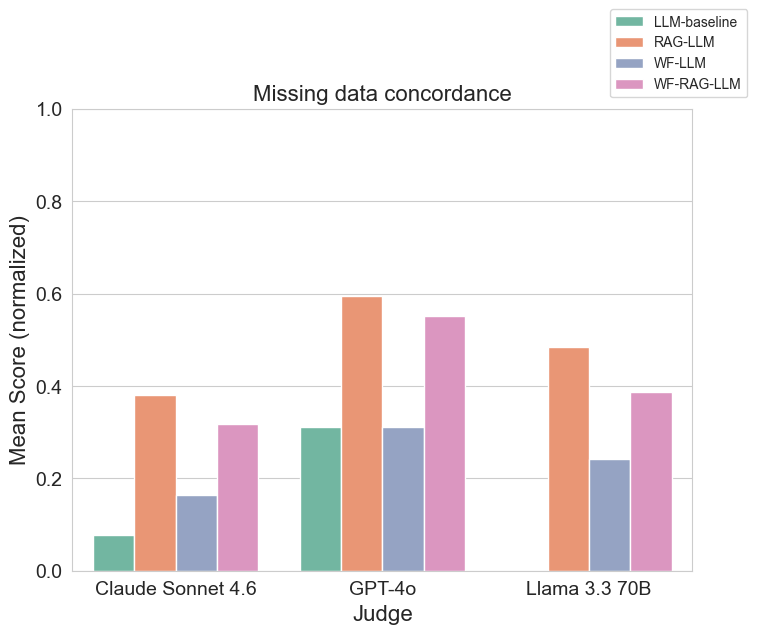

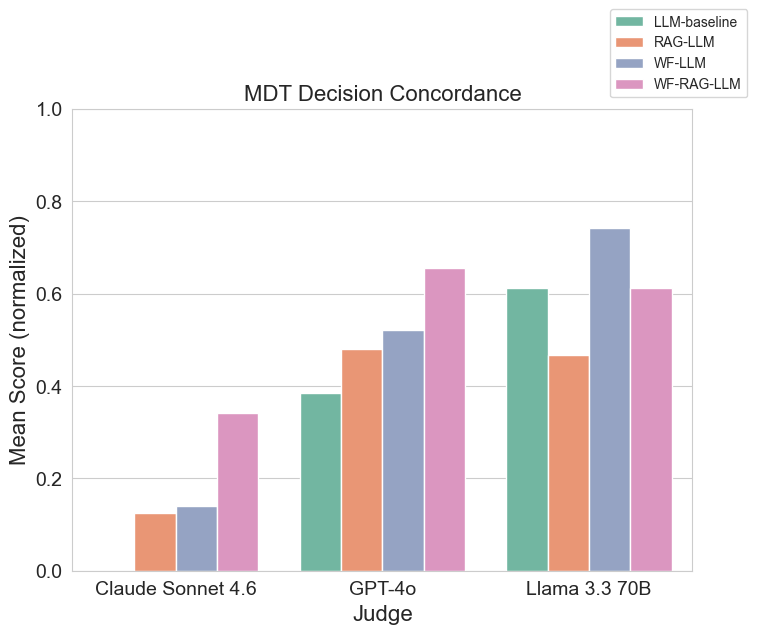

In [26]:
# Barplots
sns.set_style("whitegrid")
sns.set_palette(sns.color_palette("Set2"))

for c in criteria:
    data_plot = summary_eval_tb_for_graph.loc[summary_eval_tb_for_graph["Criterion"]==c]
    fig = plt.figure(figsize=(8, 6))
    ax = sns.barplot(data_plot, x="Judge", y="Mean_Score_Across_Iteration", hue="Approach", errorbar=None)

    x_positions = {
        cat: i for i, cat in enumerate(data_plot["Judge"].unique())
    }

    n_hue = data_plot["Approach"].nunique()
    width = 0.8 / n_hue
    plt.title(c.replace("_"," "), fontsize=16)
    plt.ylim([0,1])
    plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.23))
    plt.ylabel("Mean Score (normalized)", fontsize=16)
    plt.xlabel("Judge", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    # fig.savefig(f"{res_dir}/LLM_as_jury_{c}_normalized.png", dpi=600, format="png", bbox_inches='tight')

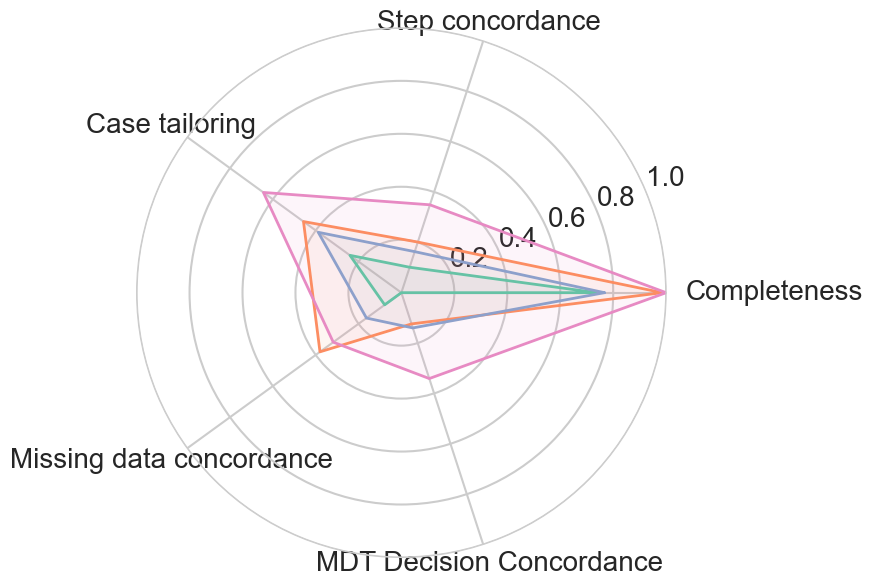

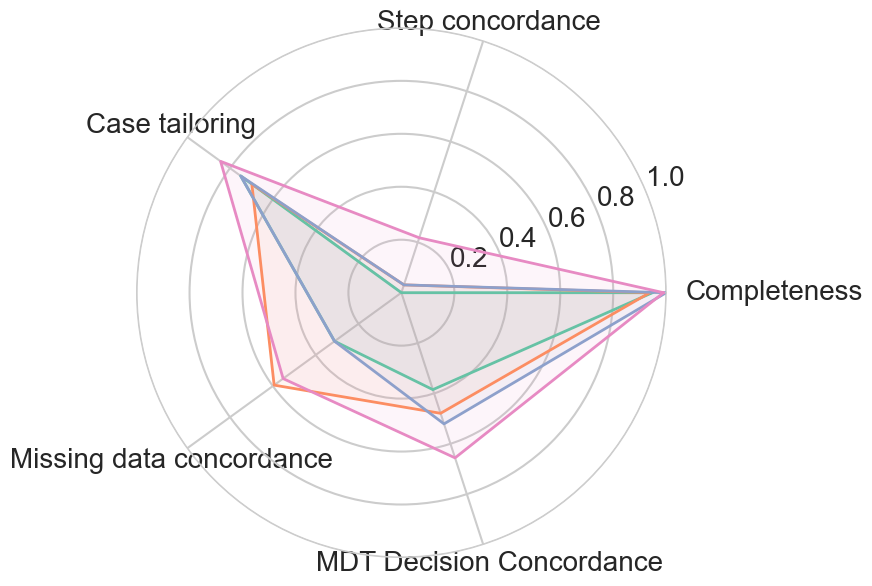

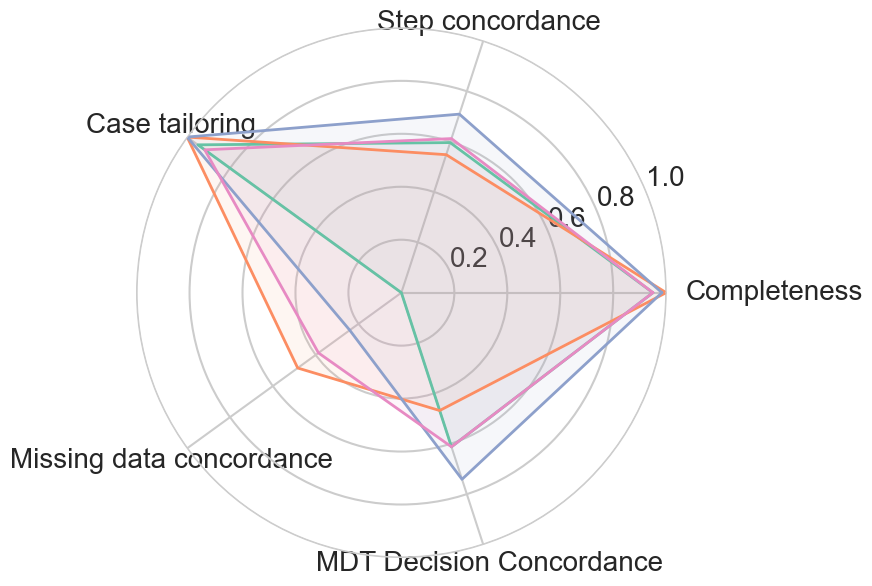

In [27]:
# Radar plots 
from sqlalchemy import label
sns.set_style("whitegrid")

n_criteria = len(criteria)
angles = np.linspace(0, 2 * np.pi, n_criteria, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

colors = sns.color_palette("Set2", len(approaches_names_map))
color_per_approach = dict(zip(approaches_names_map.values(), colors))

for judge in model_names.values():
    sub = summary_eval_tb_for_graph.loc[summary_eval_tb_for_graph["Judge"] == judge,:]

    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(polar=True))

    for a in approaches_names_map.values():
        v = []
        for c in criteria:
            match = sub.loc[(sub["Approach"] == a) & (sub["Criterion"] == c), "Mean_Score_Across_Iteration"].values[0]
            v.append(match)
        v += v[:1]  # close the polygon

        ax.plot(angles, v, linewidth=2, label=a,
                    color=color_per_approach[a])
        ax.fill(angles, v, alpha=0.08, color=color_per_approach[a])

    ax.set_xticks(angles[:-1])
    c_names = [c.replace("_"," ") for c in criteria]
    ax.set_xticklabels(c_names, fontsize=20)
    for label in ax.get_xticklabels():
        if label.get_text() == "Completeness":
            label.set_horizontalalignment("left")
    # ax.tick_params(axis='x', pad=20)

    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=20)
    # ax.legend(loc="upper right", fontsize=12, bbox_to_anchor=(1.4, 1.3))
    fig.tight_layout()

    ax.xaxis.grid(linewidth=1.5) 
    ax.yaxis.grid(linewidth=1.5)

    # fig.savefig(f"{res_dir}/{judge}_normalized_radar.png", dpi=600, format="png", bbox_inches='tight')

    plt.show()
    plt.close(fig)


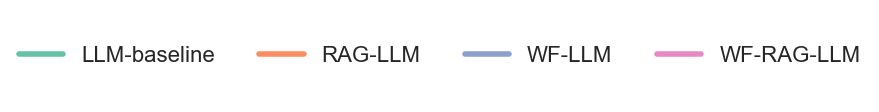

In [28]:
# Legend 
from matplotlib.lines import Line2D

legend_handles = [
    Line2D(
        [0], [0],
        color=color_per_approach[a],
        lw=4,
        label=a
    )
    for a in approaches_names_map.values()
]

# Figura dedicata alla legenda
fig_leg = plt.figure(figsize=(8, 1.2))
fig_leg.legend(
    handles=legend_handles,
    loc="center",
    ncol=len(legend_handles),   
    frameon=False,
    fontsize=16
)

plt.axis("off")
plt.show()
# fig_leg.savefig(f"{res_dir}/approach_legend.png", dpi=600, format="png", bbox_inches='tight')

In [ ]:
# Save results
eval_final_data.to_csv(f"{res_dir}/eval_final_data_normalized.csv", index=False, sep=';')
summary_eval_tb.to_csv(f"{res_dir}/LLM_as_jury_results_{n_case_eval}_cases_normalized.csv", index=False, sep=';')

### Aggregate judges final score

Aggregate by score

In [31]:
final_aggregated_score = pd.DataFrame(columns=criteria, index=approaches_names_map.values())
final_mean_score = pd.DataFrame(columns=criteria, index=approaches_names_map.values())
for a in approaches_names_map.values():
    for c in criteria:
        s_list = []
        final_score = pd.read_csv(f"{res_dir}/LLM_as_jury_results_110_cases_normalized.csv", sep=';')
        s = final_score.loc[(final_score["Approach"]==a) & (final_score["Criterion"]==c),"Mean_Score_Across_Iteration"].values
        mean_values = []
        for ss in s:
            findex = ss.find("(")
            s_mean = float(ss[0:findex-1])
            mean_values.append(s_mean)
        s_list.append(s)
        print(f"Approach {a}, criterion {c} --> {mean_values}")
        final_mean = np.mean(mean_values)
        final_std = np.std(mean_values)
        final_aggregated_score.loc[a, c] = s_list
        final_mean_score.loc[a, c] = f"{round(final_mean,3)} ({round(final_std, 3)})"

Approach LLM-baseline, criterion Completeness --> [0.737, 0.948, 0.95]
Approach LLM-baseline, criterion Step_concordance --> [0.101, 0.0, 0.596]
Approach LLM-baseline, criterion Case_tailoring --> [0.24, 0.75, 0.95]
Approach LLM-baseline, criterion Missing_data_concordance --> [0.078, 0.312, 0.0]
Approach LLM-baseline, criterion MDT_Decision_Concordance --> [0.0, 0.385, 0.612]
Approach RAG-LLM, criterion Completeness --> [0.985, 0.938, 1.0]
Approach RAG-LLM, criterion Step_concordance --> [0.201, 0.031, 0.548]
Approach RAG-LLM, criterion Case_tailoring --> [0.457, 0.698, 1.0]
Approach RAG-LLM, criterion Missing_data_concordance --> [0.38, 0.594, 0.484]
Approach RAG-LLM, criterion MDT_Decision_Concordance --> [0.124, 0.479, 0.468]
Approach WF-LLM, criterion Completeness --> [0.767, 1.0, 0.984]
Approach WF-LLM, criterion Step_concordance --> [0.163, 0.031, 0.709]
Approach WF-LLM, criterion Case_tailoring --> [0.388, 0.75, 1.0]
Approach WF-LLM, criterion Missing_data_concordance --> [0.16

In [32]:
final_mean_score

,Completeness,Step_concordance,Case_tailoring,Missing_data_concordance,MDT_Decision_Concordance
LLM-baseline,0.878 (0.1),0.232 (0.26),0.647 (0.299),0.13 (0.133),0.332 (0.253)
RAG-LLM,0.974 (0.026),0.26 (0.215),0.718 (0.222),0.486 (0.087),0.357 (0.165)
WF-LLM,0.917 (0.106),0.301 (0.293),0.713 (0.251),0.239 (0.061),0.467 (0.248)
WF-RAG-LLM,0.98 (0.022),0.393 (0.164),0.802 (0.116),0.419 (0.098),0.536 (0.139)


In [ ]:
final_aggregated_score.to_csv(f"{res_dir}/final_aggregated_results_normalized.csv", sep=';')
final_mean_score.to_csv(f"{res_dir}/final_aggregated_single_result_normalized.csv", sep=';')

Aggregate by Judge

In [35]:
final_mean_score_2 = pd.DataFrame(columns=list(model_names.values())+["Final Score"], index=approaches)
for a in approaches:
    mean_values = []
    for j in model_names.keys():
        data_a_m = eval_final_data.loc[(eval_final_data["Approach"]==a) & (eval_final_data["Judge"]==j),"Mean_Score_Normalized"].values
        mean_val = round(np.mean(data_a_m),3)
        std_val = round(np.std(data_a_m),3)
        mean_values.append(mean_val)
        final_mean_score_2.loc[a, model_names[j]] = f"{mean_val} ({std_val})"
    final_mean_score_2.loc[a, "Final Score"] = f"{round(np.mean(mean_values),3)} ({round(np.std(mean_values),3)})"

In [36]:
final_mean_score_2

,Claude Sonnet 4.6,GPT-4o,Llama 3.3 70B,Final Score
Model_Alone,0.231 (0.264),0.479 (0.335),0.622 (0.347),0.444 (0.162)
Model_Studies,0.429 (0.302),0.548 (0.3),0.7 (0.246),0.559 (0.111)
Model_Workflow,0.324 (0.239),0.523 (0.336),0.735 (0.275),0.527 (0.168)
Model_Workflow_Studies,0.53 (0.264),0.652 (0.264),0.696 (0.211),0.626 (0.07)


In [ ]:
final_mean_score_2.to_csv(f"{res_dir}/final_aggregated_single_result_normalized_v2.csv", sep=';')

### Performance by case-category

In [37]:
cases_category = pd.read_csv(f"../generation/data/HPB_cases.csv", sep=';', encoding="latin-1")
categories = set(cases_category["Category"])

In [38]:
categories_map = {"Anatomical Resectability":"Anatomical Resectability",
                  "Liver Metastases with Extra-Hepatic Disease":"LM with Extra-Hepatic Disease",
                  "Liver Recurrences After Surgery": "Liver Recurrences After Surgery",
                  "Metachronous Liver Metastases":"Metachronous LM",
                  "Metastases After Chemotherapy: Response, Stability, or Progression": "Metastases After Chemotherapy",
                  "Molecular Cases and Complex Situations":"Molecular Cases and Complex Situations",
                  "Synchronous Metastases Potentially Resectable After Chemotherapy":"Sync. LM Post-Chemo Resectable",
                  "Synchronous Resectable Liver Metastases":"Sync. Resectable LM"}

In [40]:
eval_final_data = pd.DataFrame(columns=["Approach","Judge","Criterion","Category","NValues","Mean_Score", "STD_Score", "Median_Score", "Percentiles_25_75"])
for m in model_dirs.keys():
    d = model_dirs[m]
    m_files = os.listdir(d)
    for a in approaches: 
        print(f"Approach: {a}")
        f_name = f"{d}/eval_{a}_with_explanation.csv"
        f_content = pd.read_csv(f_name, sep=';')
        for cat in categories:
            cat_cases = cases_category.loc[cases_category["Category"]==cat, "Case_Number"]
            f_content_filter = f_content.loc[f_content["Case_Number"].isin(cat_cases), :]
            print(f"Category {cat} --> {len(cat_cases)}; Cases --> {f_content_filter["Case_Number"].to_list()}")
            for c in criteria:
                c_col = f_content_filter.loc[:,c].values
                stats_ = compute_stats(c_col)
                eval_final_data.loc[len(eval_final_data)] = [a, m, c, categories_map[cat], len(f_content_filter)] + stats_[0:-1] + [f"{stats_[3][0]}-{stats_[3][1]}"]


Approach: Model_Alone
Category Synchronous Resectable Liver Metastases --> 15; Cases --> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Category Liver Recurrences After Surgery --> 13; Cases --> [51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63]
Category Metachronous Liver Metastases --> 15; Cases --> [26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
Category Metastases After Chemotherapy: Response, Stability, or Progression --> 10; Cases --> [41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
Category Anatomical Resectability --> 10; Cases --> [101, 102, 103, 104, 105, 106, 107, 108, 109, 110]
Category Synchronous Metastases Potentially Resectable After Chemotherapy --> 10; Cases --> [16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
Category Molecular Cases and Complex Situations --> 25; Cases --> [76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]
Category Liver Metastases with Extra-Hepatic Disease --> 12; Cases --> [64, 65, 66, 67, 68

In [41]:
# Normalization per model (judge)
new_columns=["Approach","Judge","Iteration","Criterion", "Category", "NValues"]
eval_final_data_normalized = pd.DataFrame(columns=new_columns)
for m in model_names.keys():
    data_normalized = eval_final_data.loc[eval_final_data["Judge"]==m, "Approach":"NValues"]
    m_r_data = eval_final_data.loc[eval_final_data["Judge"]==m, "Mean_Score"].values
    min_max_values[m] = [np.min(m_r_data), np.max(m_r_data)]
    print(f"Model judge: {m} --> len: {len(m_r_data)}; min_max: {min_max_values[m]}")
    normalized_values = (m_r_data - min_max_values[m][0])/(min_max_values[m][1]-min_max_values[m][0])
    round_values = [round(n,3) for n in normalized_values]
    data_normalized.insert(len(data_normalized.columns), "Mean_Score_Normalized", round_values)

    eval_final_data_normalized = pd.concat([eval_final_data_normalized, data_normalized])

Model judge: us.anthropic.claude-sonnet-4-6 --> len: 160; min_max: [np.float64(2.7), np.float64(5.0)]
Model judge: gpt-4o --> len: 160; min_max: [np.float64(3.4), np.float64(5.0)]
Model judge: us.meta.llama3-3-70b-instruct-v10 --> len: 160; min_max: [np.float64(3.7), np.float64(5.0)]


In [42]:
# Aggregate models 
summary_eval_tb = pd.DataFrame(columns=["Approach","Criterion","Category","NValues","Mean","STD"])
for a in approaches:
    for c in criteria:
        for cat in categories:
            agg_data = eval_final_data_normalized.loc[(eval_final_data_normalized["Approach"]==a) & (eval_final_data_normalized["Criterion"]==c) & (eval_final_data_normalized["Category"]==categories_map[cat]),"Mean_Score_Normalized"].values
            n_values = eval_final_data_normalized.loc[(eval_final_data_normalized["Approach"]==a) & (eval_final_data_normalized["Criterion"]==c) & (eval_final_data_normalized["Category"]==categories_map[cat]),"NValues"].values[0]
            print(f"Approach {a}; Criterion {c}; Category {cat} --> {agg_data}")
            stats_ = compute_stats(agg_data)
            summary_eval_tb.loc[len(summary_eval_tb)] = [approaches_names_map[a], c, categories_map[cat], n_values, stats_[0], stats_[1]]

Approach Model_Alone; Criterion Completeness; Category Synchronous Resectable Liver Metastases --> [0.768 0.958 1.   ]
Approach Model_Alone; Criterion Completeness; Category Liver Recurrences After Surgery --> [0.699 1.    0.763]
Approach Model_Alone; Criterion Completeness; Category Metachronous Liver Metastases --> [0.652 0.917 0.948]
Approach Model_Alone; Criterion Completeness; Category Metastases After Chemotherapy: Response, Stability, or Progression --> [0.565 0.813 0.615]
Approach Model_Alone; Criterion Completeness; Category Anatomical Resectability --> [0.826 0.875 0.923]
Approach Model_Alone; Criterion Completeness; Category Synchronous Metastases Potentially Resectable After Chemotherapy --> [0.739 0.875 0.846]
Approach Model_Alone; Criterion Completeness; Category Molecular Cases and Complex Situations --> [0.791 0.975 0.938]
Approach Model_Alone; Criterion Completeness; Category Liver Metastases with Extra-Hepatic Disease --> [0.71  0.896 0.808]
Approach Model_Alone; Crit

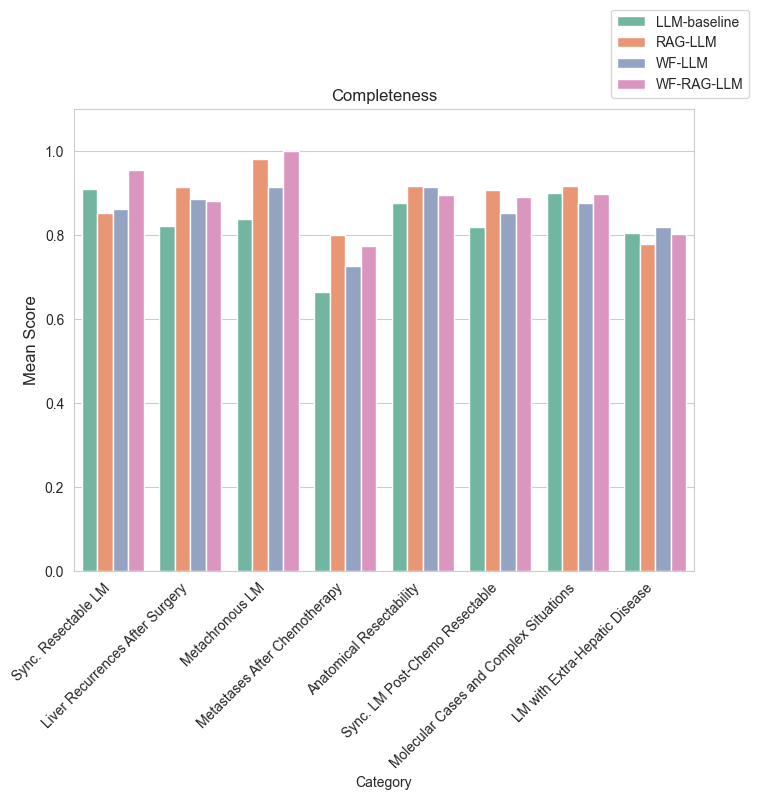

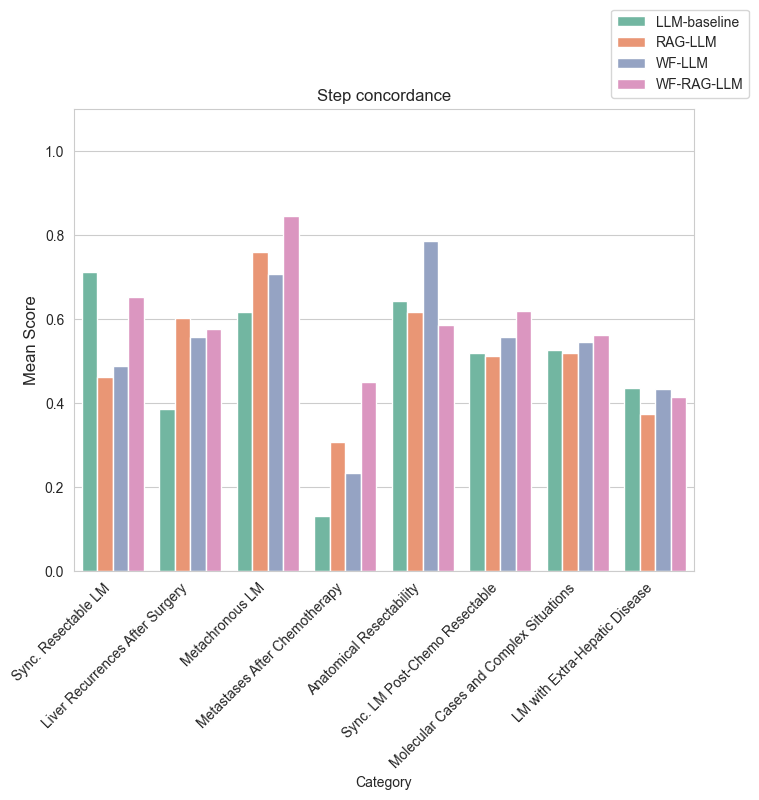

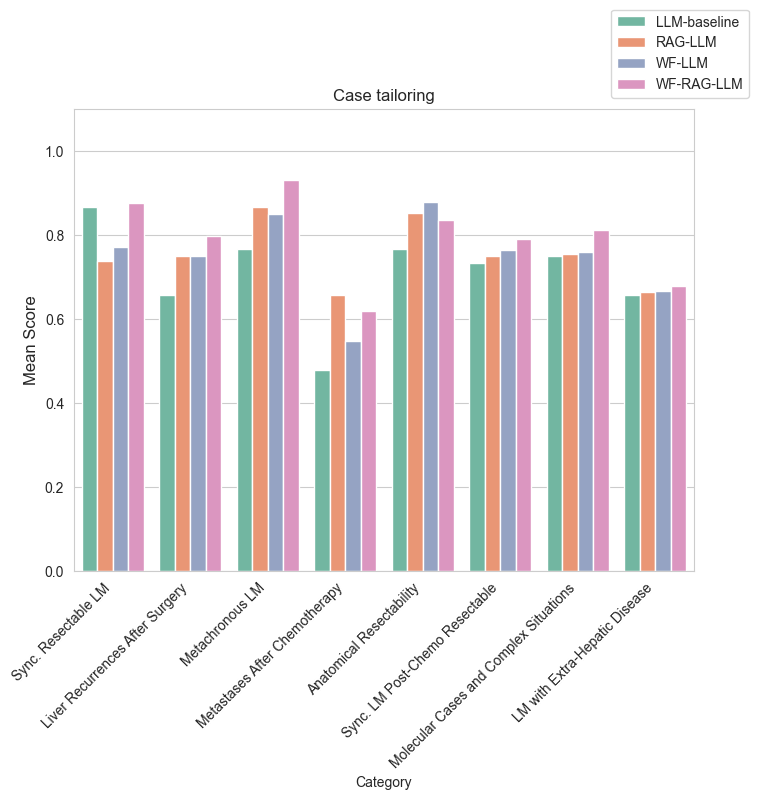

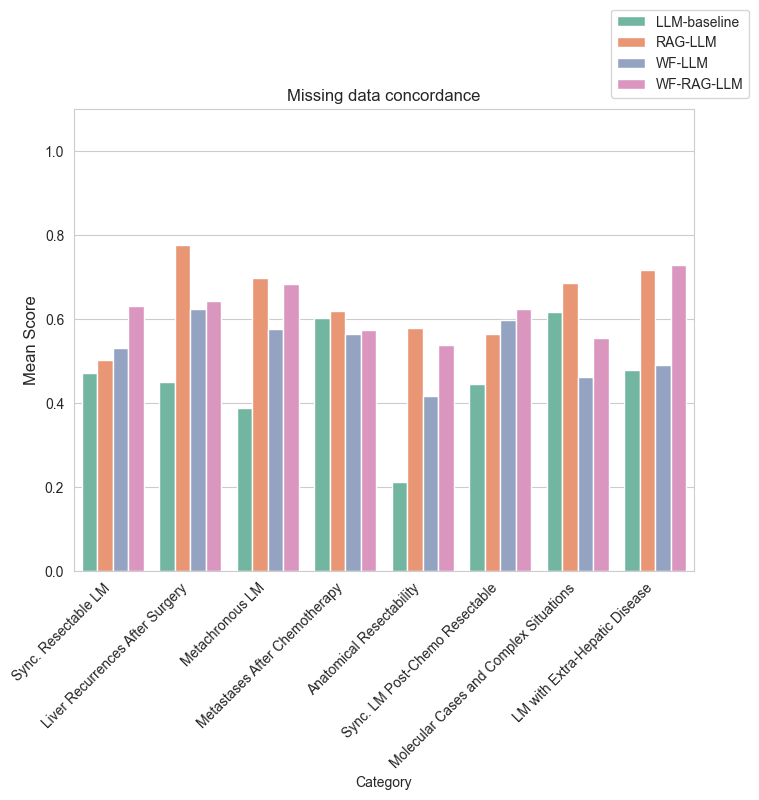

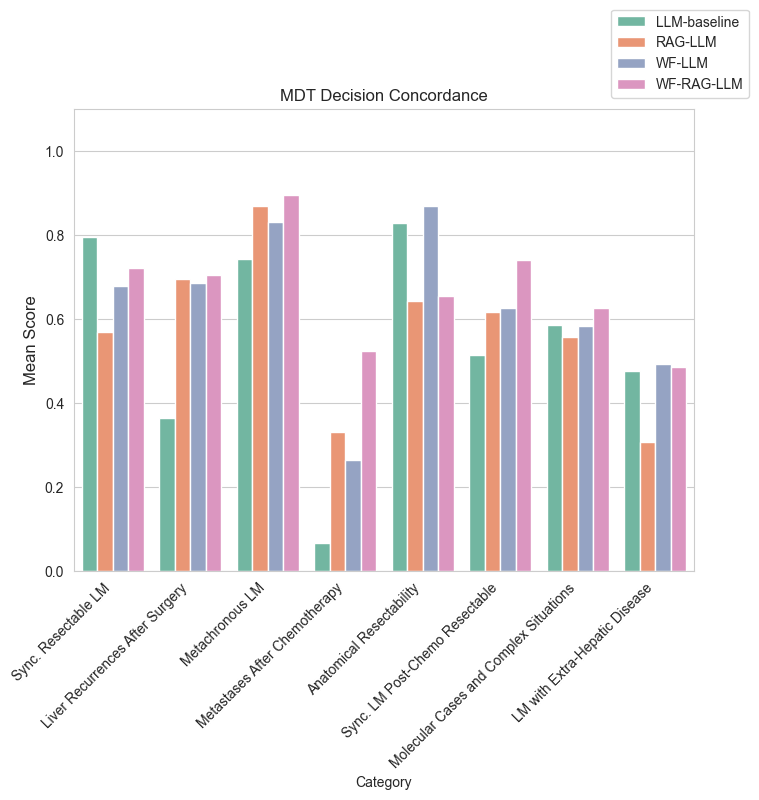

In [43]:
sns.set_style("whitegrid")
sns.set_palette(sns.color_palette("Set2"))

for c in criteria:
    data_plot = summary_eval_tb.loc[summary_eval_tb["Criterion"]==c]
    fig = plt.figure(figsize=(8, 6))
    ax = sns.barplot(data_plot, x="Category", y="Mean", hue="Approach", errorbar=None)

    x_positions = {
        cat: i for i, cat in enumerate(data_plot["Category"].unique())
    }

    n_hue = data_plot["Approach"].nunique()
    width = 0.8 / n_hue

    plt.title(c.replace("_"," "))
    plt.ylim([0,1.1])
    plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.23))
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Mean Score", fontsize=12)
    plt.show()
    # fig.savefig(f"{res_dir}/LLM_as_jury_{c}_by_category.png", dpi=600, format="png", bbox_inches='tight')

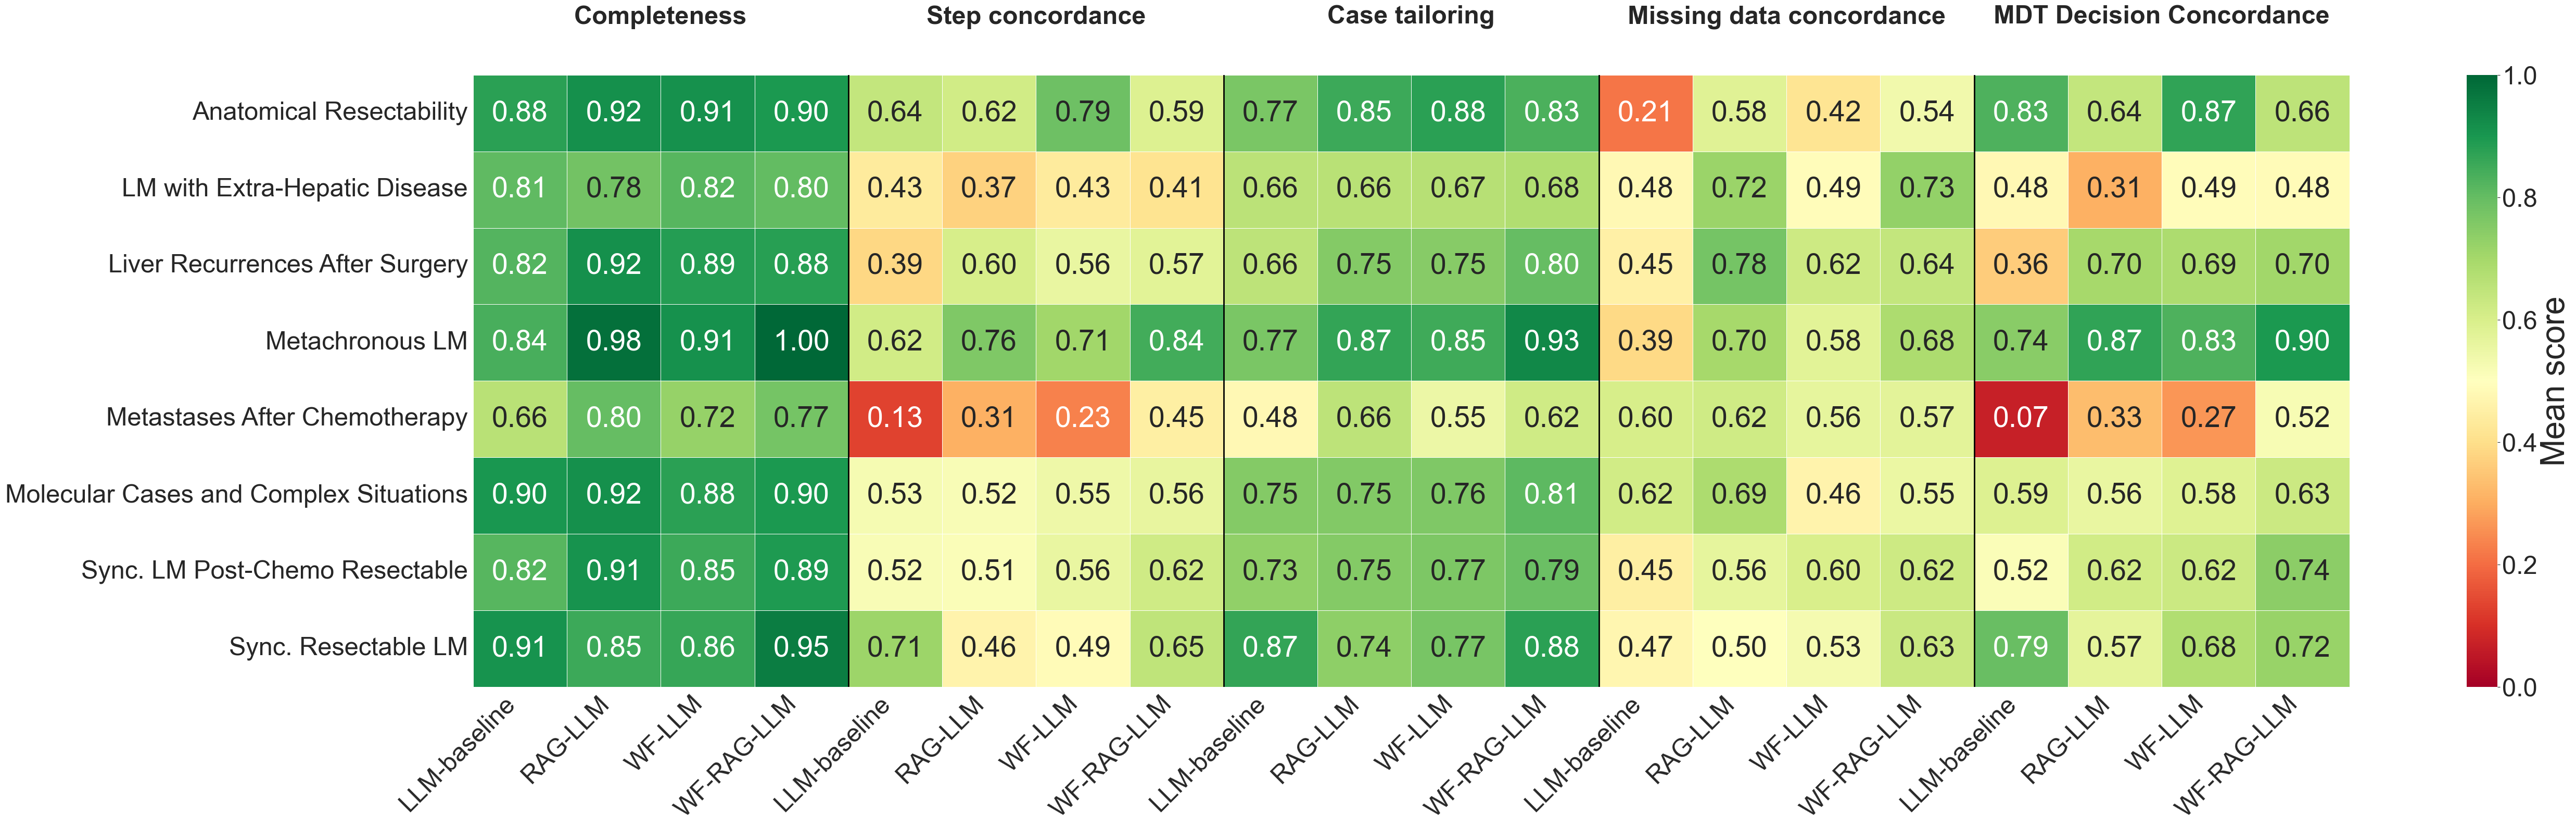

In [44]:
# Pivot table: columns = MultiIndex (criterion, approach), rows = categories
wide = summary_eval_tb.pivot_table(index="Category", columns=["Criterion", "Approach"], values="Mean")

# Riordino righe e colonne secondo l'ordine desiderato (macrogruppi = criterio, poi approccio)
col_order = [(c, a) for c in criteria for a in approaches_names_map.values() if (c, a) in wide.columns]
wide = wide.reindex(index=categories_map.values(), columns=col_order)

n_approcci = len(approaches_names_map)
n_criteri = len(criteria)

fig, ax = plt.subplots(figsize=(2.3 * len(col_order) + 2, 1.8 * len(categories) + 2))

heatmap = sns.heatmap(wide, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "Score medio (giudici)"},
            xticklabels=[a for _, a in col_order], ax=ax, annot_kws={"fontsize": 40})

ax.set_xlabel("")
ax.set_ylabel("")

for i in range(1, n_criteri):
    ax.axvline(i * n_approcci, color="black", linewidth=2)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=40)
for i, criterio in enumerate(criteria):
    centro = i * n_approcci + n_approcci / 2
    ax.text(centro, -0.6, criterio.replace("_", " "), ha="center", va="bottom",
            fontsize=35, fontweight="bold", transform=ax.transData)

cbar = heatmap.collections[0].colorbar
cbar.set_label("Mean score", fontsize=45)   # etichetta
cbar.ax.tick_params(labelsize=35)  

fig.tight_layout()
plt.xticks(fontsize=35)
plt.yticks(fontsize=35)

# fig.savefig(f"{res_dir}/LLM_as_jury_{c}_by_category.png", dpi=600, format="png", bbox_inches='tight')


plt.show()
plt.close(fig)


In [45]:
# Results analysis
summary_eval_tb_v2 = pd.DataFrame(columns=["Category", "Criterion", "Approach", "Mean score"])
summary_eval_tb_v3 = pd.DataFrame(columns=["Category", "Criterion", "Best Approach", "Improvement from baseline"])
summary_eval_tb_v4 = pd.DataFrame(columns=["Category", "Approach", "Overall Score"])

for cat in categories_map.values():
    for c in criteria:
        for a in approaches_names_map.values():
            row = summary_eval_tb.loc[(summary_eval_tb["Approach"]==a) & (summary_eval_tb["Category"]==cat) & (summary_eval_tb["Criterion"]==c), :]
            v_ = f"{row.Mean.item()} ({row.STD.item()})"
            summary_eval_tb_v2.loc[len(summary_eval_tb_v2)] = [cat, c, a, v_]

for cat in categories_map.values():
    for c in criteria:
        app_values_ = summary_eval_tb.loc[(summary_eval_tb["Category"]==cat) & (summary_eval_tb["Criterion"]==c), ["Approach","Mean"]].reset_index()
        scores = app_values_["Mean"].to_list()
        max_value = np.max(scores)
        baseline_max = np.max(scores[0:2])
        for i in range(0, len(app_values_)):
            if app_values_.loc[i, "Mean"] == max_value:
                best_m = app_values_.loc[i, "Approach"]
                best_value = app_values_.loc[i, "Mean"]
                break
        if best_m == "WF-LLM" or best_m == "WF-RAG-LLM":
            imp = best_value - baseline_max
        else:
            imp = '-'

        summary_eval_tb_v3.loc[len(summary_eval_tb_v3)] = [cat, c, best_m, imp]

for cat in categories_map.values():
    for a in approaches_names_map.values():
        values_ = summary_eval_tb.loc[(summary_eval_tb["Category"]==cat) & (summary_eval_tb["Approach"]==a), "Mean"].values
        m_value = np.mean(values_)
        summary_eval_tb_v4.loc[len(summary_eval_tb_v4)] = [cat, a, m_value]

print(len(summary_eval_tb_v2), len(summary_eval_tb_v3), len(summary_eval_tb_v4))


160 40 32


In [ ]:
eval_final_data.to_csv(f"{res_dir}/eval_final_data_by_category.csv",sep=';',index=False)
eval_final_data_normalized.to_csv(f"{res_dir}/eval_final_data_normalized_by_category.csv",sep=';',index=False)
summary_eval_tb.to_csv(f"{res_dir}/LLM_as_jury_results_{n_case_eval}_cases_by_category.csv", sep=';', index=False)

### Statistical Comparison

In [46]:
criteria

['Completeness',
 'Step_concordance',
 'Case_tailoring',
 'Missing_data_concordance',
 'MDT_Decision_Concordance']

In [49]:
from scipy import stats
from itertools import combinations
from statsmodels.stats.multitest import multipletests

stats_data = {m: {c: [] for c in criteria} for m in model_dirs.keys()}
for m in model_dirs.keys():
    for c in criteria:
        for a in approaches:
            data_a = pd.read_csv(f"{model_dirs[m]}/eval_{a}_with_explanation.csv", sep=';')
            data_a_c = data_a.loc[:, c].values
            stats_data[m][c].append(data_a_c)

pairwise_results = []  
friedman_results = []

for m in stats_data.keys():
    for c_name in stats_data[m].keys():
        groups = stats_data[m][c_name]  

        # Friedman omnibus test
        friedman_stat = stats.friedmanchisquare(*groups)
        print(f"Judge: {m}; Criterion: {c_name} --> Friedman p={friedman_stat.pvalue:.4f}")
        friedman_results.append({
            'judge': m, 'criterion': c_name, 'friedman p-value': round(friedman_stat.pvalue, 4)
        })

        # Post-hoc Wilcoxon pairwise if Friedman is significant
        if friedman_stat.pvalue < 0.05:
            comparisons = []
            for i, j in combinations(range(len(approaches)), 2):
                stat, p = stats.wilcoxon(groups[i], groups[j])
                comparisons.append({
                    'label': f"{approaches[i]} vs {approaches[j]}",
                    'p_raw': p,
                    'mean_1': round(np.mean(groups[i])),
                    'mean_2': round(np.mean(groups[j])),
                    'interquartile_1': [round(np.percentile(groups[i], 10)), round(np.percentile(groups[i], 90))],
                    'interquartile_2': [round(np.percentile(groups[j], 10)), round(np.percentile(groups[j], 90))],
                    'mean_diff': round(np.mean(groups[i] - groups[j]), 3)
                })

            pair_pvals = [c['p_raw'] for c in comparisons]
            reject, pvals_corrected, _, _ = multipletests(pair_pvals, method='holm')

            for c, p_corr, rej in zip(comparisons, pvals_corrected, reject):
                print(f"    {c['label']}: p_raw={c['p_raw']:.4f}, p_holm={p_corr:.4f}, significant={rej}")
                pairwise_results.append({
                    'judge': m, 'criterion': c_name, 'comparison': c['label'],
                    'mean_1': c['mean_1'], 'mean_2': c['mean_2'],
                    'interquartile_1': c['interquartile_1'], 'interquartile_2': c['interquartile_2'],
                    'mean_diff': c['mean_diff'],
                    'p_raw': c['p_raw'], 'p_holm': p_corr, 'significant': rej
                })

results_df_1 = pd.DataFrame(friedman_results)
results_df_2 = pd.DataFrame(pairwise_results)
        

Judge: us.anthropic.claude-sonnet-4-6; Criterion: Completeness --> Friedman p=0.0000
    Model_Alone vs Model_Studies: p_raw=0.0000, p_holm=0.0001, significant=True
    Model_Alone vs Model_Workflow: p_raw=0.5752, p_holm=1.0000, significant=False
    Model_Alone vs Model_Workflow_Studies: p_raw=0.0000, p_holm=0.0000, significant=True
    Model_Studies vs Model_Workflow: p_raw=0.0001, p_holm=0.0004, significant=True
    Model_Studies vs Model_Workflow_Studies: p_raw=0.7055, p_holm=1.0000, significant=False
    Model_Workflow vs Model_Workflow_Studies: p_raw=0.0000, p_holm=0.0001, significant=True
Judge: us.anthropic.claude-sonnet-4-6; Criterion: Step_concordance --> Friedman p=0.0018
    Model_Alone vs Model_Studies: p_raw=0.0579, p_holm=0.1738, significant=False
    Model_Alone vs Model_Workflow: p_raw=0.3139, p_holm=0.6278, significant=False
    Model_Alone vs Model_Workflow_Studies: p_raw=0.0001, p_holm=0.0004, significant=True
    Model_Studies vs Model_Workflow: p_raw=0.5396, p_hol

In [24]:
results_df_2.head()

,judge,criterion,comparison,mean_1,mean_2,interquartile_1,interquartile_2,mean_diff,p_raw,p_holm,significant
0,claude,Completeness,Model_Alone vs Model_Studies,4,5,"[4, 5]","[4, 5]",-0.291,1.924537e-05,0.000077,True
1,claude,Completeness,Model_Alone vs Model_Workflow,4,4,"[4, 5]","[4, 5]",-0.036,5.752086e-01,1.000000,False
2,claude,Completeness,Model_Alone vs Model_Workflow_Studies,4,5,"[4, 5]","[4, 5]",-0.309,9.366605e-07,0.000006,True
3,claude,Completeness,Model_Studies vs Model_Workflow,5,4,"[4, 5]","[4, 5]",0.255,1.387885e-04,0.000416,True
4,claude,Completeness,Model_Studies vs Model_Workflow_Studies,5,5,"[4, 5]","[4, 5]",-0.018,7.054570e-01,1.000000,False


In [ ]:
results_df_1.to_csv(f"{res_dir}/friedman_results.csv", sep=';', index=False)
results_df_2.to_csv(f"{res_dir}/pairwise_results.csv", sep=';', index=False)

### Step 1: Resectability Compliance Comparison

In [ ]:
# Read the resectability labels extracted from Step3 --> in data path
data_dir = "./data/"
label_data = pd.read_csv(f"{data_dir}{version}/compliance.csv", sep=';', encoding="utf-8")

In [51]:
labels=["C", "NC"]

In [52]:
labels_approach = {a:[] for a in approaches} 
for a in approaches:
    model_labels = label_data.loc[:, f"Label_{a}"].to_list()
    if len(model_labels) != n_case_eval:
        print(f"Warning with approach {a}; {len(model_labels)}")
    else:
        labels_approach[a] = model_labels

In [53]:
expert_labels = label_data.loc[:, "Label_Expert"].to_list()
print(len(expert_labels))

110


In [ ]:
# Accuracy table
acc_tb = pd.DataFrame(columns=["Accuracy"], index=approaches)
for a in labels_approach.keys():
    true_s = 0
    for i in range(0, len(expert_labels)):
        if labels_approach[a][i] == expert_labels[i]:
            true_s += 1
    acc = round(true_s/len(expert_labels),3)
    acc_tb.loc[a, "Accuracy"] = acc

# acc_tb.to_csv(f"{res_dir}/resectability_accuracy.csv")
        

In [55]:
# Per-label Accuracy table
acc_tb = pd.DataFrame(columns=[f"Count_{l}" for l in labels]+[f"Accuracy_{l}" for l in labels], index=approaches)
for a in labels_approach.keys():
    #print(f"Approach: {a}")
    true_s = {l:0 for l in labels}
    for i in range(0, len(expert_labels)):
        if labels_approach[a][i] == expert_labels[i]:
            true_s[expert_labels[i]] += 1
    for l in labels:
        #print(f"Label: {l}; {true_s[l]}/{len([t for t in expert_labels if t == l])}")
        acc = round(true_s[l]/len([t for t in expert_labels if t == l]),3)
        acc_tb.loc[a, f"Count_{l}"] = len([t for t in expert_labels if t == l])
        acc_tb.loc[a, f"Accuracy_{l}"] = acc

# acc_tb.to_csv(f"{res_dir}/resectability_accuracy_per_label.csv")

In [56]:
# Performance report 
p_columns = ["precision", "recall", "f1-score", "support"]
dfs = {approaches_names_map[app]:None for app in approaches}
for a in approaches:
    res_tb = pd.DataFrame(columns=p_columns, index=labels+["macro avg"])
    # print(f"Approach: {a}")
    rep = classification_report(expert_labels, labels_approach[a], target_names=labels, output_dict=True)
    for k in ["C", "NC", "macro avg"]:
        res_tb.loc[k, :] = [round(rep[k]["precision"],3), round(rep[k]["recall"],3), round(rep[k]["f1-score"],3), round(rep[k]["support"],3)]
    res_tb.to_csv(f"{res_dir}/resectability_performance_report_{a}.csv", sep=';')
    dfs[approaches_names_map[a]] = res_tb

In [57]:
res_tb

,precision,recall,f1-score,support
C,0.904,0.895,0.899,95.0
NC,0.375,0.4,0.387,15.0
macro avg,0.64,0.647,0.643,110.0


       class precision recall f1-score support      approach
0          C     0.864  0.937    0.899    95.0  LLM-baseline
1         NC     0.143  0.067    0.091    15.0  LLM-baseline
2  macro avg     0.503  0.502    0.495   110.0  LLM-baseline
3          C     0.868  0.968    0.915    95.0       RAG-LLM
4         NC      0.25  0.067    0.105    15.0       RAG-LLM


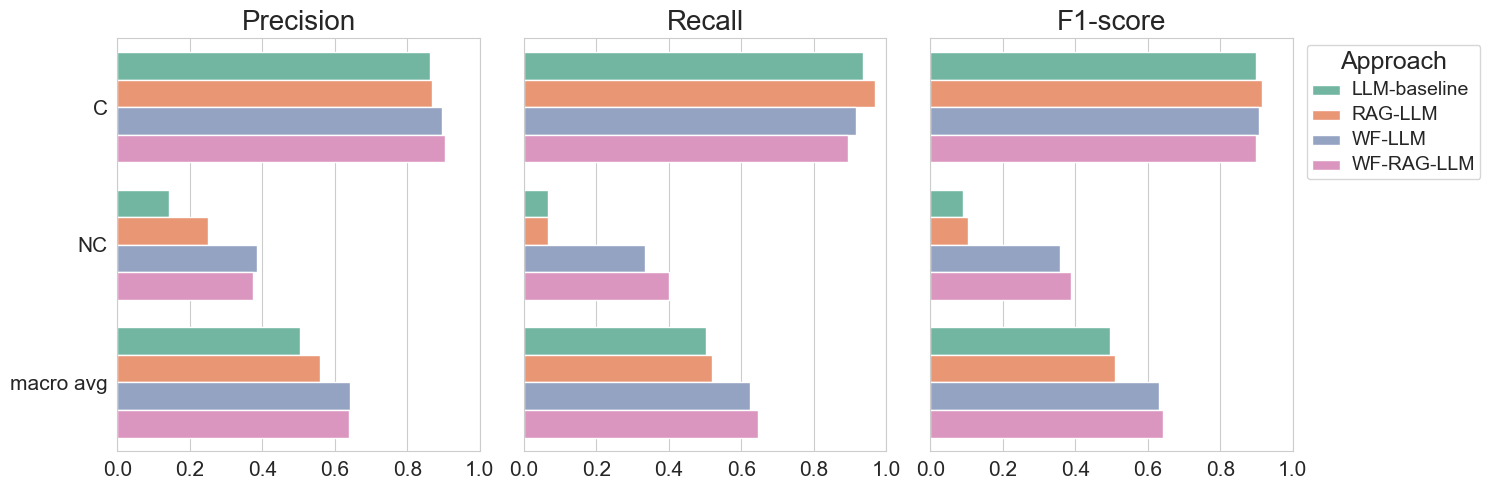

In [58]:
# Compare performance reports 
# Build a long format dataframe for all approaches
long_dfs = []
for approach, df in dfs.items():
    tmp = df.reset_index().rename(columns={'index': 'class'})  # se 'class' è l'index
    tmp['approach'] = approach
    long_dfs.append(tmp)

df_long = pd.concat(long_dfs, ignore_index=True)
print(df_long.head())

metrics = ['precision', 'recall', 'f1-score']  
classes_order = ['C', 'NC', 'macro avg']
approach_order = list(dfs.keys())

# Barplots
sns.set_style("whitegrid")
sns.set_palette(sns.color_palette("Set2"))

fig, axes = plt.subplots(1, len(metrics), figsize=(5*len(metrics), 5), sharey=True)

for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=df_long,
        y='class', x=metric, hue='approach',
        order=classes_order, hue_order=approach_order,
        ax=ax
    )
    ax.set_title(metric.capitalize(), fontsize=20)
    ax.set_xlabel("", fontsize=15)
    ax.set_ylabel('', fontsize=20)
    ax.tick_params(axis='y', labelsize=15)
    ax.tick_params(axis='x', labelsize=15)
    ax.set_xlim(0, 1)
    ax.legend_.remove() if ax != axes[-1] else None

legend = axes[-1].legend(title='Approach', bbox_to_anchor=(1.02, 1), loc='upper left')
legend.get_title().set_fontsize(18)      # font del titolo "Approach"
for text in legend.get_texts():
    text.set_fontsize(14) 
plt.tight_layout()
# plt.savefig(f"{res_dir}/compliance_performance.png", dpi=600, format="png", bbox_inches='tight')
plt.show()

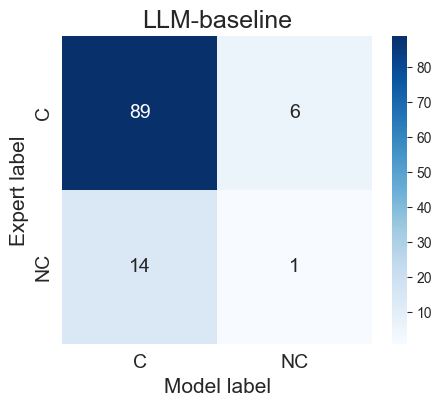

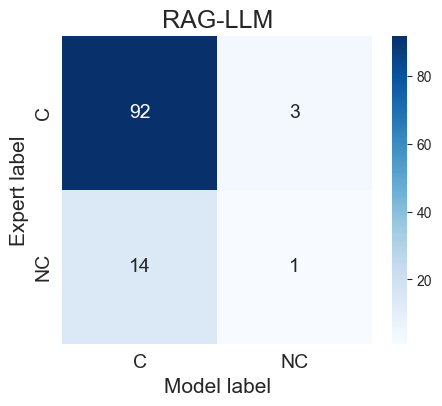

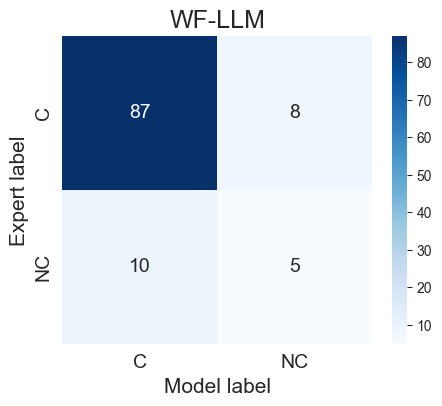

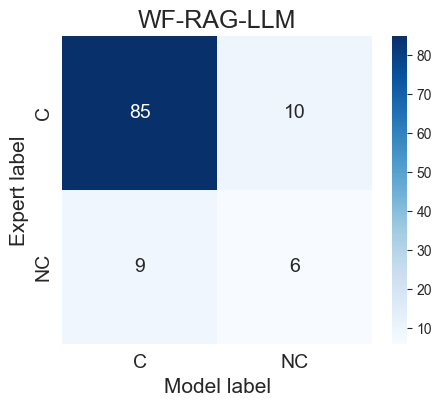

In [59]:
# Confusion matrix
for a in labels_approach.keys():
    cm = confusion_matrix(expert_labels, labels_approach[a], labels=labels)
    fig = plt.figure(figsize=(5,4))
    ax = sns.heatmap(cm, cmap="Blues", annot=True, xticklabels=labels, yticklabels=labels, annot_kws={"size": 14})
    plt.ylabel('Expert label', fontsize=15)
    plt.xlabel('Model label', fontsize=15)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    plt.title(approaches_names_map[a], fontsize=18)
    # fig.savefig(f"{res_dir}/compliance_confusion_matrix_{a}.png", dpi=600, format="png", bbox_inches='tight')
    

### NER Analysis Results

In [64]:
labels = ["Biomarker", "Cancer_Surgery", "Imaging_Test", "Staging", "Therapy"]
metrics = ["TSR", "Levenshtein", "Exact_Match_P"]
data_dir = f"results_ner/" # add version path if needed 

In [65]:
# Check the number of cases for each metric results 
semantic_data = {m:{s: {a: {} for a in approaches} for s in ["Step2", "Step3"]} for m in metrics}

for m in metrics:
    for s in ["Step2", "Step3"]:
        for a in approaches:
            data_dict = {}
            data = pd.read_csv(f"{data_dir}NER_semantic_metric_{a}_{s}.csv", sep=';')
            data_m = data.loc[data["Metric"]==m]
            entity = set(data_m["Label"])
            for e in entity:
                data_m_e = data_m.loc[data_m["Label"]==e]
                if len(data_m_e) != n_case_eval:
                    print(f"Warning <data_len> for {m} data, Approach: {a}, Entity: {e}")
                else:
                    data_dict[e] = data_m_e
            semantic_data[m][s][a] = data_dict


In [66]:
print("Semantic Data")
for m in semantic_data.keys():
    for s in semantic_data[m].keys():
        for a in semantic_data[m][s].keys():
            for e in semantic_data[m][s][a].keys():
                print(f"Metric {m}, Step {s}, Approach {a}, Label: {e} --> {len(semantic_data[m][s][a][e])}")

Semantic Data
Metric TSR, Step Step2, Approach Model_Alone, Label: Grade --> 110
Metric TSR, Step Step2, Approach Model_Alone, Label: Therapy --> 110
Metric TSR, Step Step2, Approach Model_Alone, Label: Histological_Type --> 110
Metric TSR, Step Step2, Approach Model_Alone, Label: Tumor_Size --> 110
Metric TSR, Step Step2, Approach Model_Alone, Label: Biomarker_Result --> 110
Metric TSR, Step Step2, Approach Model_Alone, Label: Staging --> 110
Metric TSR, Step Step2, Approach Model_Alone, Label: Response_To_Treatment --> 110
Metric TSR, Step Step2, Approach Model_Alone, Label: Tumor_Finding --> 110
Metric TSR, Step Step2, Approach Model_Alone, Label: Imaging_Test --> 110
Metric TSR, Step Step2, Approach Model_Alone, Label: Oncogene --> 110
Metric TSR, Step Step2, Approach Model_Alone, Label: Cancer_Surgery --> 110
Metric TSR, Step Step2, Approach Model_Alone, Label: Biomarker --> 110
Metric TSR, Step Step2, Approach Model_Alone, Label: Invasion --> 110
Metric TSR, Step Step2, Approach 

In [67]:
# Compute statistics of each metric across cases 
# Semantic metrics 
for s in ["Step2", "Step3"]:
    sem_stats = pd.DataFrame(columns=["Approach", "Label", "Metric", "Mean", "STD", "Median", "Percentiles_25-75"])
    for m in metrics:
        for a in semantic_data[m][s].keys():
            # for e in semantic_data[m][s][a].keys():
            # Consider only a subset of labels 
            for e in labels:
                stats = statistics(semantic_data[m][s][a][e]["Value"].to_list())
                sem_stats.loc[len(sem_stats)] = [approaches_names_map[a], e, m] + list(stats.values())
    # sem_stats.to_csv(f"{res_dir}NER_semantic_metric_stats_{s}.csv", sep=';')

In [69]:
# Summary table: stats across labels
summary_tb = pd.DataFrame(columns=["Approach", "Step", "Metric", "Mean_Across_Label", "STD_Across_Label"])
for m in metrics:
    for a in approaches:
        for s in ["Step2", "Step3"]:
            sem_stats = pd.read_csv(f"{data_dir}NER_semantic_metric_stats_{s}.csv", sep=';')
            data_m_a = sem_stats.loc[(sem_stats["Metric"]==m) & (sem_stats["Approach"]==approaches_names_map[a]), "Mean"].to_list()
            if len(data_m_a) != len(labels):
                print(f"Warnings with metric {m}, Approach {a}")
            else:
                stats = [round(np.mean(data_m_a),2), round(np.std(data_m_a),2)]
                summary_tb.loc[len(summary_tb)] = [approaches_names_map[a], s, m] + stats

# summary_tb.to_csv(f"{res_dir}NER_semantic_metric_summary_stats.csv", sep=';', index=False)

Warnings with metric TSR, Approach Model_Alone
Warnings with metric TSR, Approach Model_Alone
Warnings with metric TSR, Approach Model_Studies
Warnings with metric TSR, Approach Model_Studies
Warnings with metric TSR, Approach Model_Workflow
Warnings with metric TSR, Approach Model_Workflow
Warnings with metric TSR, Approach Model_Workflow_Studies
Warnings with metric TSR, Approach Model_Workflow_Studies
Warnings with metric Levenshtein, Approach Model_Alone
Warnings with metric Levenshtein, Approach Model_Alone
Warnings with metric Levenshtein, Approach Model_Studies
Warnings with metric Levenshtein, Approach Model_Studies
Warnings with metric Levenshtein, Approach Model_Workflow
Warnings with metric Levenshtein, Approach Model_Workflow
Warnings with metric Levenshtein, Approach Model_Workflow_Studies
Warnings with metric Levenshtein, Approach Model_Workflow_Studies
Warnings with metric Exact_Match_P, Approach Model_Alone
Warnings with metric Exact_Match_P, Approach Model_Alone
Warnin

C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\3331293404.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["TSR", "Levenshtein", "Exact Match (%)"], fontsize=15)
C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\3331293404.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


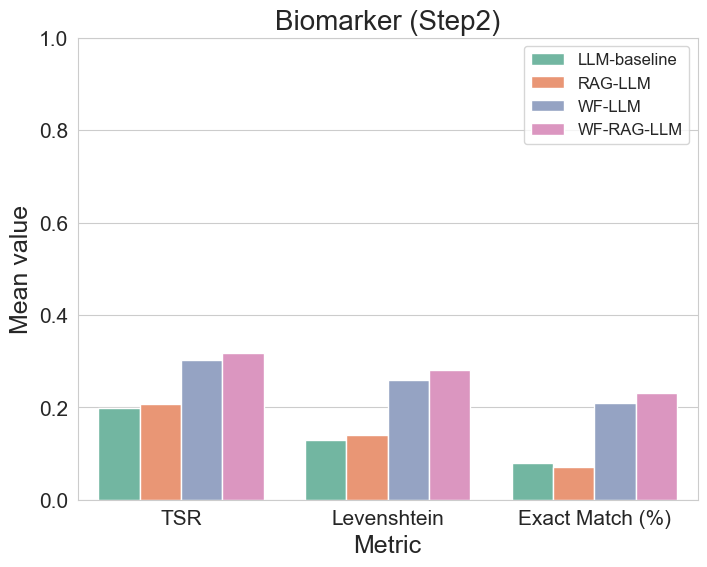

C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\3331293404.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["TSR", "Levenshtein", "Exact Match (%)"], fontsize=15)
C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\3331293404.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


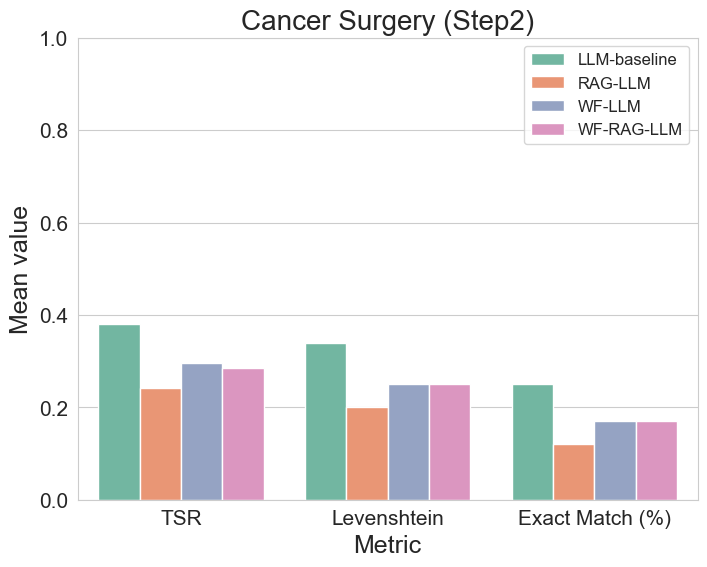

C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\3331293404.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["TSR", "Levenshtein", "Exact Match (%)"], fontsize=15)
C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\3331293404.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


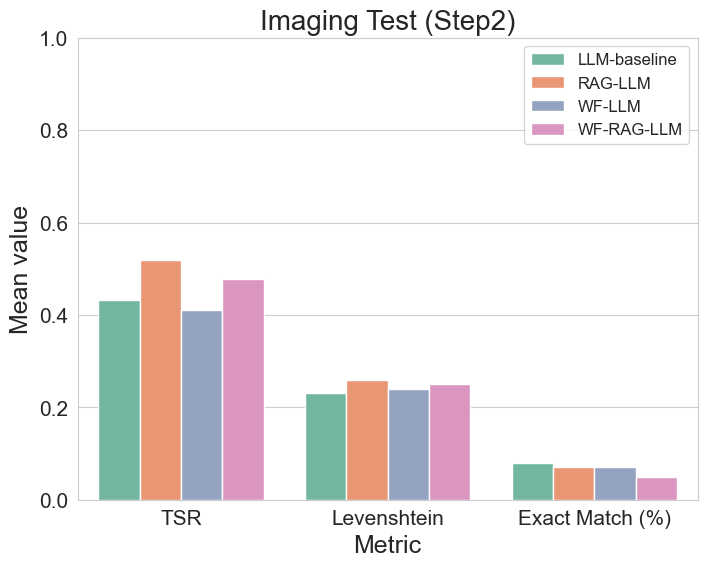

C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\3331293404.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["TSR", "Levenshtein", "Exact Match (%)"], fontsize=15)
C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\3331293404.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


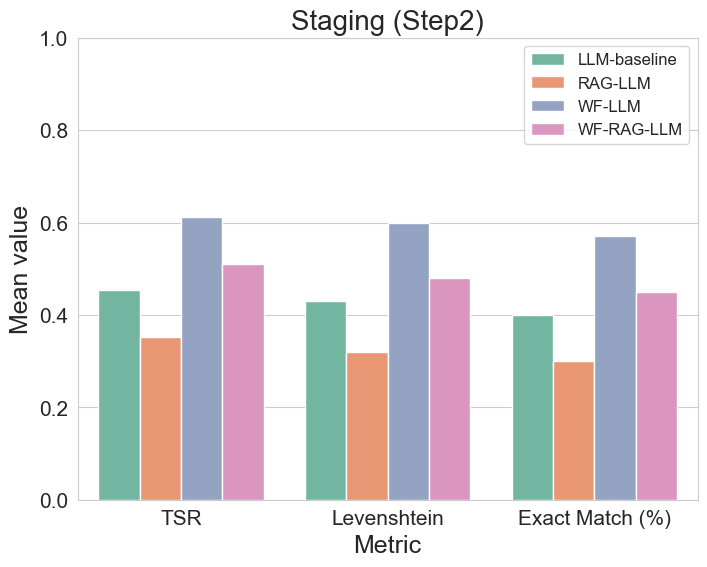

C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\3331293404.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["TSR", "Levenshtein", "Exact Match (%)"], fontsize=15)
C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\3331293404.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


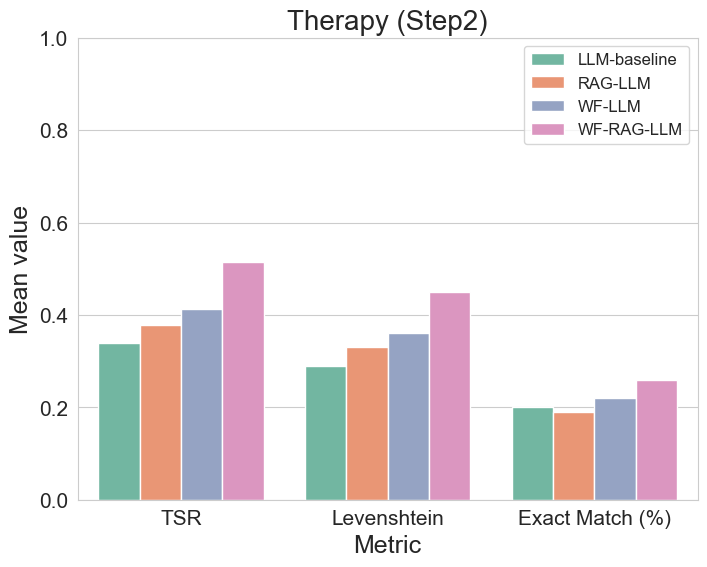

In [71]:
# Images for Step 2
# Bring TSR to the same scale 
s = "Step2"
labels_selected = ["Biomarker", "Cancer_Surgery", "Imaging_Test", "Staging", "Therapy"]
sem_data = pd.read_csv(f"{data_dir}NER_semantic_metric_stats_{s}.csv", sep=';')
sem_data.loc[sem_data["Metric"]=="TSR", "Mean"] = sem_data.loc[sem_data["Metric"]=="TSR", "Mean"]/100
# print(sem_data.loc[sem_stats_step2["Metric"]=="TSR"][1:3])

sns.set_style("whitegrid")
sns.set_palette(sns.color_palette("Set2"))

for l in labels_selected:
    data_plot = sem_data.loc[sem_data["Label"]==l]

    fig = plt.figure(figsize=(8, 6))
    ax = sns.barplot(data_plot, x="Metric", y="Mean", hue="Approach")
    plt.title(f"{l.replace("_", " ")} ({s})", fontsize=20)
    plt.ylim([0,1])
    plt.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize=12)
    ax.set_xticklabels(["TSR", "Levenshtein", "Exact Match (%)"], fontsize=15)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)
    plt.xlabel("Metric", fontsize=18)
    plt.ylabel("Mean value", fontsize=18)
    plt.show()
    # fig.savefig(f"{res_dir}{s}_{l}.png", dpi=600, format="png", bbox_inches='tight')

C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\3972655201.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["TSR", "Levenshtein", "Exact Match (%)"], fontsize=15)
C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\3972655201.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


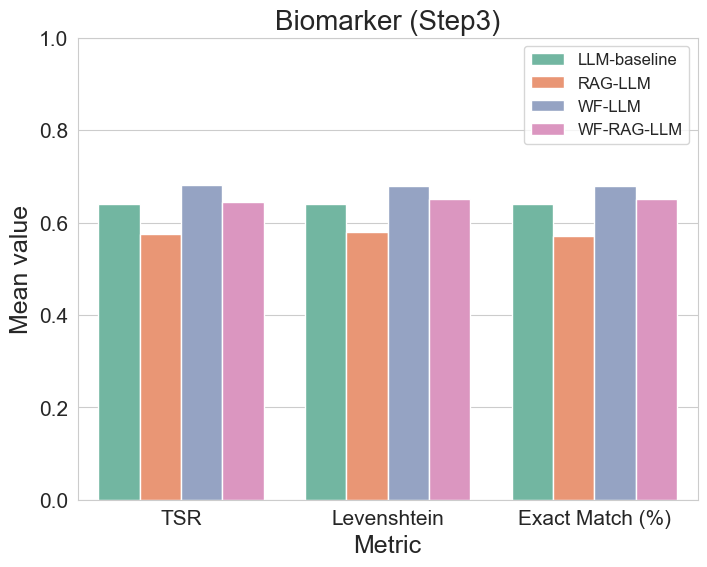

C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\3972655201.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["TSR", "Levenshtein", "Exact Match (%)"], fontsize=15)
C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\3972655201.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


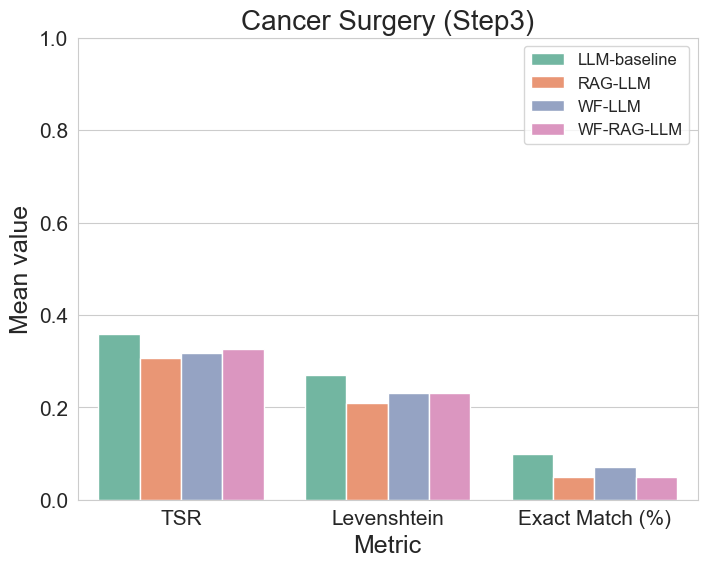

C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\3972655201.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["TSR", "Levenshtein", "Exact Match (%)"], fontsize=15)
C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\3972655201.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


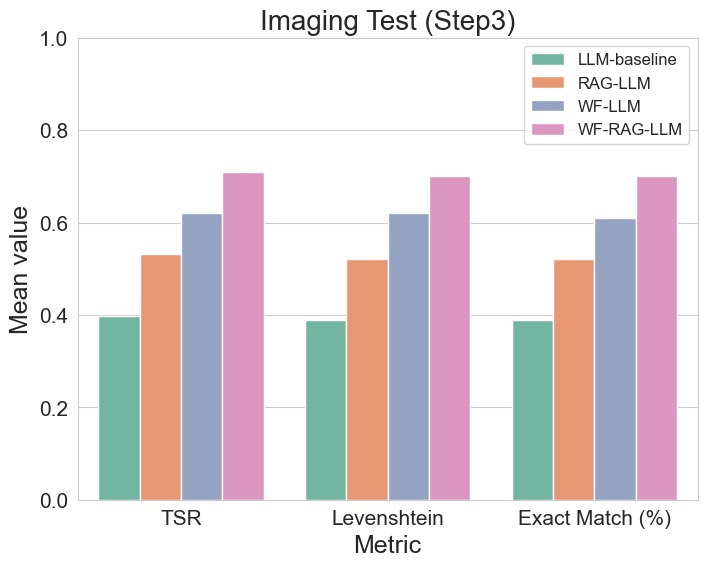

C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\3972655201.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["TSR", "Levenshtein", "Exact Match (%)"], fontsize=15)
C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\3972655201.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


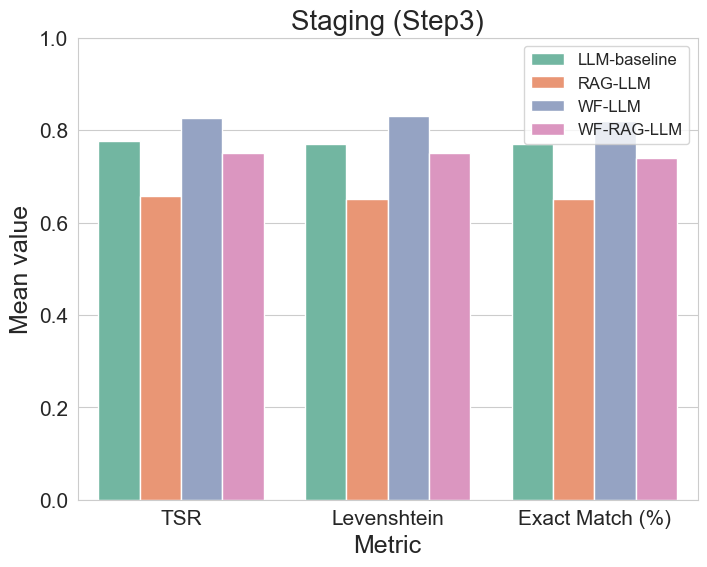

C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\3972655201.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["TSR", "Levenshtein", "Exact Match (%)"], fontsize=15)
C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\3972655201.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


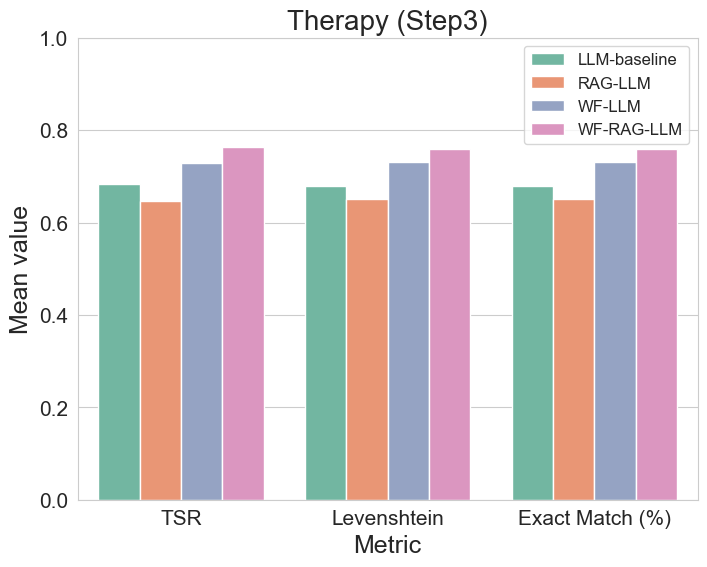

In [72]:
# Images for Step 3
# Bring TSR to the same scale 
s = "Step3"
labels_selected = ["Biomarker", "Cancer_Surgery", "Imaging_Test", "Staging", "Therapy"]
sem_data = pd.read_csv(f"{data_dir}NER_semantic_metric_stats_{s}.csv", sep=';')
sem_data.loc[sem_data["Metric"]=="TSR", "Mean"] = sem_data.loc[sem_data["Metric"]=="TSR", "Mean"]/100

sns.set_style("whitegrid")
sns.set_palette(sns.color_palette("Set2"))

for l in labels_selected:
    data_plot = sem_data.loc[sem_data["Label"]==l]

    fig = plt.figure(figsize=(8, 6))
    ax = sns.barplot(data_plot, x="Metric", y="Mean", hue="Approach")
    plt.title(f"{l.replace("_", " ")} ({s})", fontsize=20)
    plt.ylim([0,1])
    plt.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize=12)
    ax.set_xticklabels(["TSR", "Levenshtein", "Exact Match (%)"], fontsize=15)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)
    plt.xlabel("Metric", fontsize=18)
    plt.ylabel("Mean value", fontsize=18)
    plt.show()
    # fig.savefig(f"{res_dir}{s}_{l}.png", dpi=600, format="png", bbox_inches='tight')

C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\1527067363.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([l.replace("_", " ") for l in labels_selected], rotation=45, ha='right', fontsize=15)
C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\1527067363.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


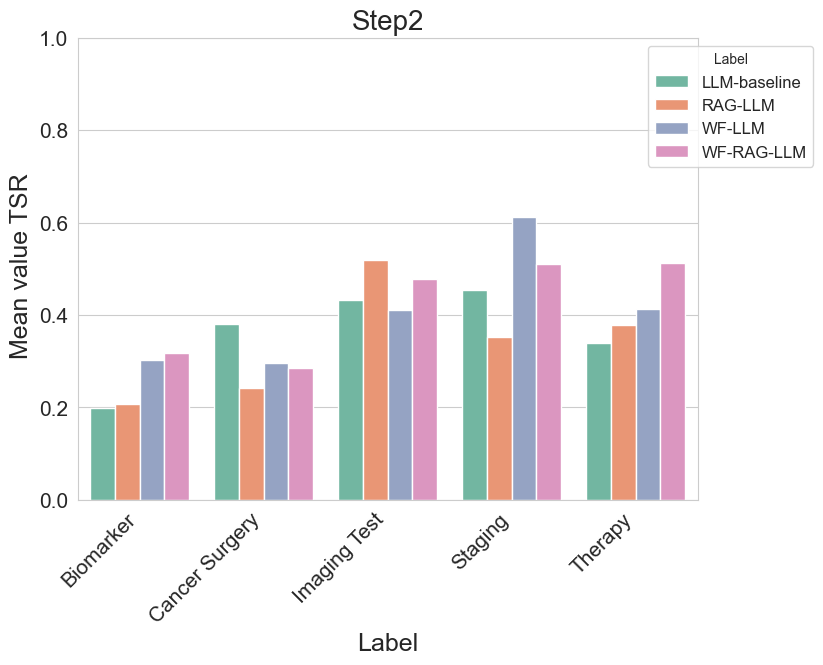

C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\1527067363.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([l.replace("_", " ") for l in labels_selected], rotation=45, ha='right', fontsize=15)
C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\1527067363.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


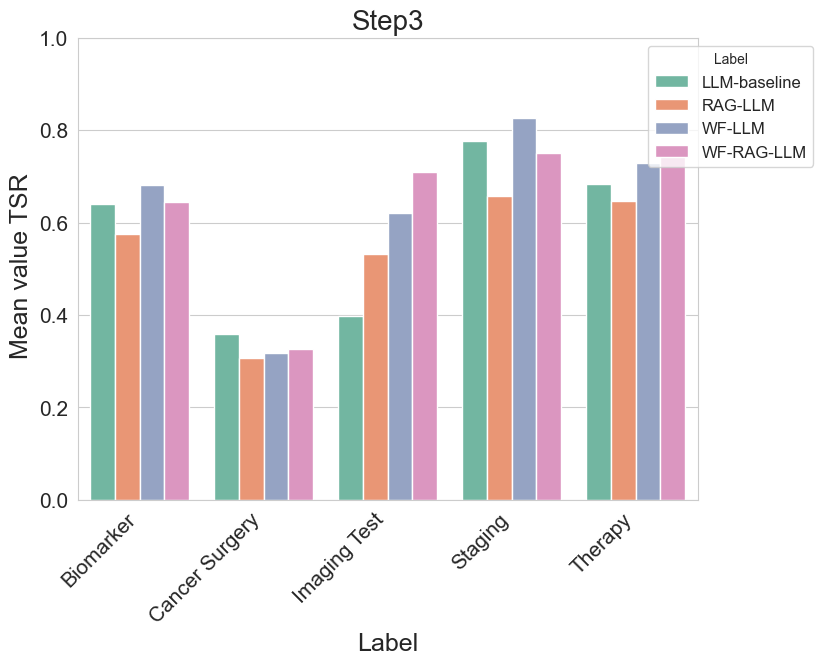

C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\1527067363.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([l.replace("_", " ") for l in labels_selected], rotation=45, ha='right', fontsize=15)
C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\1527067363.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


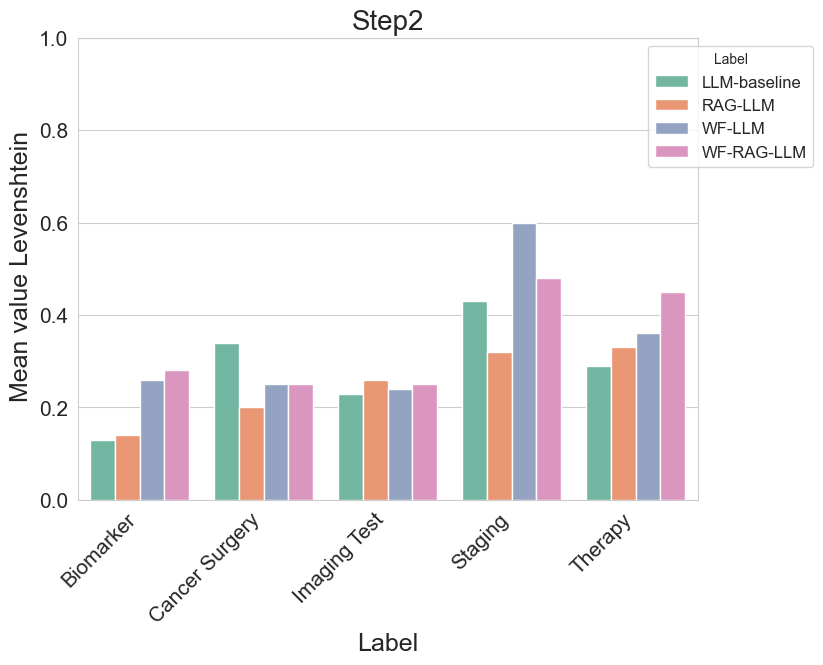

C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\1527067363.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([l.replace("_", " ") for l in labels_selected], rotation=45, ha='right', fontsize=15)
C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\1527067363.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


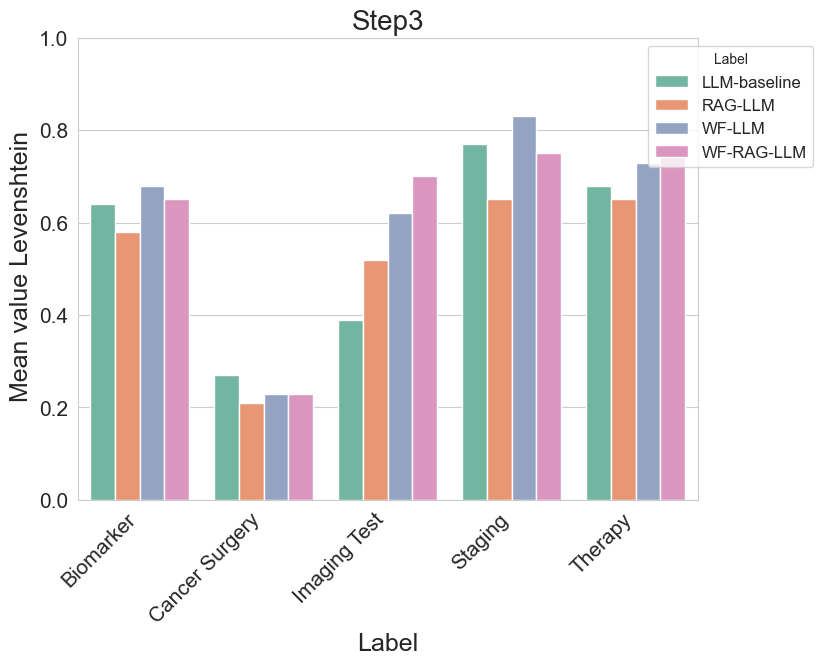

C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\1527067363.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([l.replace("_", " ") for l in labels_selected], rotation=45, ha='right', fontsize=15)
C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\1527067363.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


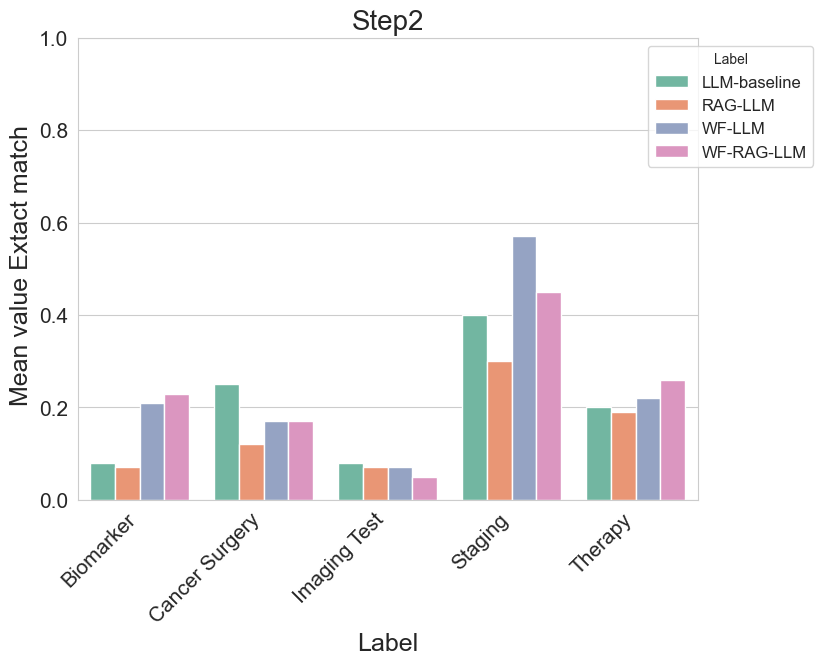

C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\1527067363.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([l.replace("_", " ") for l in labels_selected], rotation=45, ha='right', fontsize=15)
C:\Users\Admin\AppData\Local\Temp\ipykernel_11120\1527067363.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)


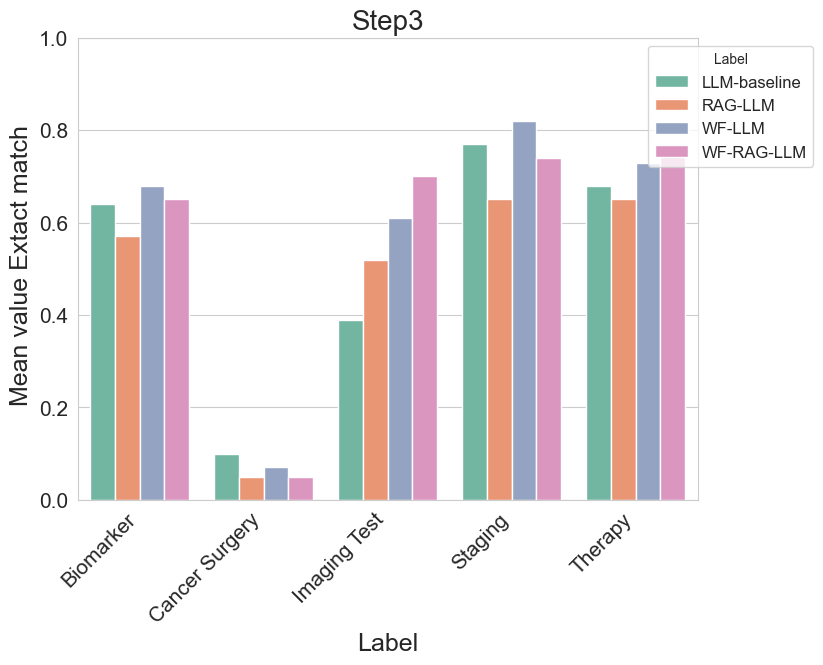

In [73]:
labels_selected = ["Biomarker", "Cancer_Surgery", "Imaging_Test", "Staging", "Therapy"]
# Images for Step 2 & 3
# Bring TSR to the same scale 
sem_data_2 = pd.read_csv(f"{data_dir}NER_semantic_metric_stats_Step2.csv", sep=';')
sem_data_2.loc[sem_data_2["Metric"]=="TSR", "Mean"] = sem_data_2.loc[sem_data_2["Metric"]=="TSR", "Mean"]/100
sem_data_3 = pd.read_csv(f"{data_dir}NER_semantic_metric_stats_Step3.csv", sep=';')
sem_data_3.loc[sem_data_3["Metric"]=="TSR", "Mean"] = sem_data_3.loc[sem_data_3["Metric"]=="TSR", "Mean"]/100

# select labels
sem_data_2 = sem_data_2.loc[sem_data_2["Label"].isin(labels_selected)]
sem_data_3 = sem_data_3.loc[sem_data_3["Label"].isin(labels_selected)]

sns.set_style("whitegrid")
sns.set_palette(sns.color_palette("Set2"))
metrics_names = {"TSR":"TSR", "Levenshtein": "Levenshtein", "Exact_Match_P": "Extact match"}

for m in metrics:
    data_plot_2 = sem_data_2.loc[sem_data_2["Metric"]==m]
    data_plot_3 = sem_data_3.loc[sem_data_3["Metric"]==m]
    data_plot = [data_plot_2, data_plot_3]
    for d, s in zip(data_plot, ["Step2", "Step3"]):
        fig = plt.figure(figsize=(8, 6))
        ax = sns.barplot(d, x="Label", y="Mean", hue="Approach")
        ax.set_ylim([0,1])
        ax.set_xticklabels([l.replace("_", " ") for l in labels_selected], rotation=45, ha='right', fontsize=15)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=15)
        ax.set_xlabel('Label', fontsize=18)
        ax.set_ylabel(f" Mean value {metrics_names[m]}", fontsize=18)
        ax.set_title(s, fontsize=20)
        ax.legend(title='Label', loc='upper right', bbox_to_anchor=(1.20, 1), fontsize=12)

        plt.show()

        # fig.savefig(f"{res_dir}{s}_{m}.png", dpi=600, format="png", bbox_inches='tight')